# Management Analyst: Cancellation Rate Improvement
### Created By : Ridwan & Reyner

# Section 1: Business Understanding

## Context

Hotel A, a mid-sized hospitality provider located in Portugal, The hotel reservation cancellation rate has reached 37%, leading to an estimated revenue loss of around 16.7 million (≈39.15% of the total potential revenue). The goal of this project is to predict the likelihood of cancellations so that the hotel can take preventive measures, such as applying overbooking strategies or implementing stricter deposit policies. As a data analyst at Hotel A, the allocated role in this situoation is to support both the management team and the marketing team by:
- Adressing cancellation rate which impacts hotel capacity management;
- Understanding customers' consideration for cancelling that can be forwarded to marketing team for policy creation;
- Discovering patterns of cancellation that might point to some segments of interest.

## Problem Statement

High booking cancellation rates present a serious challenge to hotel operations. Each time a cancellation occurs, a room that could otherwise be sold remains empty, resulting in lost revenue and reduced operational efficiency. In an industry highly dependent on capacity planning, this uncertainty is extremely harmful. Therefore, the hotels require a system that can predict which reservations are at high risk of being canceled.

*Nature of the Problem:*
- Many customers cancel their bookings suddenly, sometimes even after previously canceling multiple times.
- Several booking features show patterns associated with cancellations, such as `deposit_type`, `previous_cancellations`, `lead_time`, or `market_segment`.
- There is no current data-driven system to help hotel staff anticipate potential cancellations early.

*Objectives:*
- Build a **predictive model** using machine learning to identify whether a booking (`is_canceled`) is at high risk of cancellation.
- Reduce the number of actual cancellations by providing early warnings based on model predictions.
- Provide **clear insights** for the reservation and marketing teams to inform deposit policies, booking channels, or promotional strategies.

**What happens if this is not addressed?**
- Lower occupancy rate and reduced Average Daily Rate (ADR).
- Lost revenue opportunities from other potential customers.
- Operational costs that outweigh actual revenue.

---

## Goals

Through this project, hotel management aims to gain the ability to predict whether a reservation is at high risk of cancellation. With this predictive model, the hotels can proactively design strategies, such as deposit policies or targeted customer approaches, to reduce cancellations and increase revenue.

From a technical perspective, the project aims to:
- > Develop a classification model capable of predicting `is_canceled` (0 = not canceled, 1 = canceled).
- > Achieve at least **80% F1 Score** on the test set, ensuring a balance between precision and recall so the predictions are reliable in real business settings.
- > Provide feature importance interpretation to highlight which booking attributes (e.g., `deposit_type`, `lead_time`, `adr`) have the strongest influence on cancellations.

---

## Analytical Approach

The chosen approach is to build a classification model that predicts whether a booking will be canceled or not. The steps include:

- **Identify Cancellation Patterns from Historical Data**  
  Analyze features such as `deposit_type`, `lead_time`, `adr` (average daily rate), `market_segment`, `previous_cancellations`, and `days_in_waiting_list` to uncover patterns linked to customer cancellation behavior.

- **Prepare Relevant Features**  
  Perform feature selection and engineering to strengthen the model’s ability to detect cancellation signals. For example, grouping country data (`country`), encoding categorical variables like `meal` or `distribution_channel`, and scaling numerical features.

- **Build Classification Models**  
  Apply supervised learning algorithms (e.g., Logistic Regression, Random Forest, XGBoost) to map booking features to the target label `is_canceled`.

- **Handle Class Imbalance**  
  Since about 63% of bookings are not canceled and 37% are canceled, balancing techniques such as SMOTE or class weighting will be applied.

- **Optimize Accuracy and Business Usefulness**  
  Focus on evaluation metrics such as F1 Score, Precision, and Recall to balance detection of cancellations with avoiding excessive false alarms.

This approach aims to produce not only accurate predictions but also actionable business insights for hotel strategy.

---


## Evaluation Metrics

| Actual (Row) \ Predicted (Col)         | Won't cancel the booking (0) | Will cancel the booking (1) |
|-----------------------------|--------------------------------|-------------------------------|
| **Won't cancel the booking (0)** | **True Negative (TN)**<br>Model predicts that customer won't cancel their booking, they don't cancel the booking | **False Positive (FP)**<br>Model predicts that customer will cancel their booking, while actually not cancelling |
| **Will cancel the booking (1)**   | **False Negative (FN)**<br>Model predicts that customer won't cancel their booking while actually they are cancelling | **True Positive (TP)**<br>Model predicts that customer will cancel their booking, they cancel the booking |

<br>

### Cost Simulation for Misclassification

In the context of hotel bookings, each type of misclassification brings a different business impact:

- **(FN)**  
  Model predicts *Not Canceled* but the booking is actually *Canceled*.  
  - Impact: The room remains empty, leading to a direct revenue loss.  
  - Example:  
    - Average ADR: €100  
    - Average stay: 4 nights  
    - Lost revenue = 100 × 4 = €400  
    - Additional operational cost (e.g., staffing, cleaning, utilities): ~€50  
    - **Total cost per FN ≈ €450**

- **(FP)**  
  Model predicts *Canceled* but the booking is actually *Not Canceled*.  
  - Impact: Hotel may impose unnecessary restrictions, potentially discouraging genuine guests.  
  - Example:  
    - Average ADR: €100  
    - Average stay: 4 nights  
    - If the guest cancels due to stricter policies, lost revenue = €400  
    - Assume not all guests leave, only ~50% are discouraged → expected cost ≈ €200  
    - **Total cost per FP ≈ €200**

<br>

| Error Type        | Key Business Consequences                                                       |
|-------------------|----------------------------------------------------------------------------------|
| **False Negative**| High-risk cancellation not detected → empty room, revenue loss (**450**)                 |
| **False Positive**| Valid booking wrongly flagged as canceled → poor customer experience, reputation (**200**) |

<br>

> From this simulation, **False Negatives are more expensive than False Positives**. Therefore, the model should prioritize reducing FN, even at the cost of slightly higher FP.

### Choice of Evaluation Metrics

Given the class imbalance (63% not canceled vs 37% canceled) and the different business costs of misclassification, we select metrics that capture both technical and financial performance.

- **Primary Metric: PR-AUC (Precision-Recall Area Under Curve)**  
  - More appropriate than ROC-AUC in imbalanced settings.  
  - Focuses directly on the positive class (cancellations), which is the core of our business problem.  
  - Summarizes the trade-off between precision (avoiding false alarms) and recall (catching actual cancellations).  

- **Supporting Metrics:**  
  - **Recall** → to ensure we minimize False Negatives, since each missed cancellation costs the hotel significant lost revenue.  
  - **Precision** → to control False Positives and avoid discouraging genuine customers.  
  - **F1 Score** → to provide a single balanced view of precision and recall.  
  - **Business Cost Simulation** → using the confusion matrix multiplied by estimated cost per FP (€200) and FN (€450) to evaluate the financial impact of model predictions.  

---

**Insight:**  
By making **PR-AUC the primary metric**, we align the technical evaluation with the business need: detecting cancellations effectively in an imbalanced dataset. Secondary metrics and cost simulation ensure that the chosen model not only performs well statistically but also minimizes real-world financial losses.

---

## Expected Outcomes

- Reduce potential revenue loss by anticipating cancellations before they happen.
- Provide hotel staff with early alerts on risky bookings, enabling proactive actions (e.g., deposit requests).
- Improve operational efficiency through more accurate room and resource planning.
- Support marketing teams with insights into booking behaviors (e.g., channels with higher cancellation rates).

---

## Limitations and Challenges

- **Imbalanced dataset**: Majority of bookings are not canceled, which can bias the model.
- **Geographic limitation**: Data only covers hotels in Portugal, so insights may not generalize globally.
- **Customer tracking limitation**: No customer ID, so repeat bookings by the same customer cannot be identified.
- **External factors not included**: Events like pandemics, economic downturns, or seasonal changes may affect cancellations but are not captured in the dataset.
- **Interpretability**: Model outputs need to be simplified so non-technical hotel staff can understand and use them effectively.

---
---

In [2]:
# Limit CPU usage for numerical libraries
import os
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["VECLIB_MAXIMUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

In [3]:
# Library
import pandas as pd
import numpy as np

# # Google Colab
# from google.colab import files

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
from IPython.display import display

# EDA Libraries
from skrub import TableReport

# Feature Engineering
from sklearn.base import clone
from feature_engine.encoding import RareLabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split, cross_val_score, cross_validate, LearningCurveDisplay, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, make_scorer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import roc_curve, roc_auc_score

# Imbalance Library
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP
import shap

# Model Output
import joblib

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [4]:
path = "hotel_bookings.csv"
df = pd.read_csv(path)

In [5]:
display(df.head(), df.tail())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [6]:
# # General table report
# report = TableReport(df, max_plot_columns=32, max_association_columns=32)
# report

In [7]:
print("General Information:")
display(df.info())
print("")

print("5 First Rows:")
display(df.head())
print("")

print("5 Last Rows:")
display(df.tail())
print("")

print("5 Random Rows:")
display(df.sample(5))

General Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  


None


5 First Rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



5 Last Rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07



5 Random Rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
59814,City Hotel,1,135,2016,November,45,2,1,4,2,0.0,0,BB,BRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,90.0,0,0,Canceled,2016-06-29
115780,City Hotel,0,28,2017,July,28,9,2,0,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,2,No Deposit,9.0,NaN,0,Transient,149.0,0,1,Check-Out,2017-07-11
95991,City Hotel,0,12,2016,August,35,26,0,1,2,0.0,0,BB,NZL,Online TA,TA/TO,0,0,0,D,E,0,No Deposit,9.0,NaN,0,Transient,164.0,0,1,Check-Out,2016-08-27
20693,Resort Hotel,0,21,2016,February,6,5,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,E,2,No Deposit,NaN,NaN,0,Transient,35.0,0,1,Check-Out,2016-02-07
63990,City Hotel,1,28,2017,February,8,25,2,2,3,0.0,0,BB,ITA,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,134.3,0,0,Canceled,2017-02-02


In [8]:
print("Numerical Summary:")
display(df.describe())

print("Categorical Summary:")
display(df.describe(include='object'))


Numerical Summary:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Categorical Summary:


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


# Section 2: Data Understanding

The dataset contains booking records from **two types of hotels in Portugal — a Resort Hotel and a City Hotel — between July 2015 and August 2017**, totaling more than **119,000 reservations**. This dataset is compiled from multiple records of hotels in Portugal, accessed as part of the hotel association agreement. Each row represents **one reservation**, and each column provides information about booking characteristics, customer details, or operational aspects. It is important to understand identifier for companies, customers, or other privacy breach is removed or modified accordingly.

---

## 2.1 Data Source
The dataset comes from a collection of hotel booking records provided by partner hotels operating in Portugal, covering both city hotels and resort hotels.  
For privacy reasons, the actual hotel names have been anonymized, and any personally identifiable information (PII) has been removed.  

The dataset is compiled into a single CSV file (`hotel_bookings.csv`), which can be accessed directly without restrictions for analysis and modeling purposes.


## 2.2 Feature Information

The dataset consists of **32 features**, a mix of categorical and numerical variables, with the target column `is_canceled`.

| **Feature Name**              | **Data Type** | **Description**                                                                 | **Impact to Business**                                                                                                    |
|--------------------------------|---------------|---------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------|
| `hotel`                       | object        | Type of hotel (Resort Hotel or City Hotel).                                      | Compare cancellation rates between hotel types to adjust business strategies.                                              |
| `is_canceled`                 | int64         | Whether the booking was canceled (1) or not (0).                                 | Target variable for prediction; directly linked to business problem.                                                       |
| `lead_time`                   | int64         | Number of days between booking date and arrival date.                            | Long lead times are often associated with higher cancellation probability.                                                 |
| `arrival_date_year`           | int64         | Year of arrival.                                                                 | Helps analyze cancellation trends over years.                                                                              |
| `arrival_date_month`          | object        | Month of arrival (January–December).                                             | Captures seasonality in cancellations.                                                                                     |
| `arrival_date_week_number`    | int64         | Week number of the arrival date (1–52).                                          | Enables weekly trend analysis of bookings and cancellations.                                                               |
| `arrival_date_day_of_month`   | int64         | Day of the month of arrival.                                                     | Helps identify daily patterns of cancellations.                                                                            |
| `stays_in_weekend_nights`     | int64         | Number of weekend nights (Saturday/Sunday) the guest stayed or booked.           | Reveals impact of weekend demand on cancellation patterns.                                                                 |
| `stays_in_week_nights`        | int64         | Number of weeknights (Monday–Friday) the guest stayed or booked.                 | Indicates length of weekday stays; longer stays may be linked to higher cancellations.                                     |
| `adults`                      | int64         | Number of adults in the booking.                                                 | Insight into customer demographics; solo vs. family/group bookings may differ in stability.                                |
| `children`                    | float64       | Number of children in the booking.                                               | Families with children may be less likely to cancel.                                                                      |
| `babies`                      | int64         | Number of babies in the booking.                                                 | Helps identify family-oriented reservations.                                                                               |
| `meal`                        | object        | Type of meal plan booked (e.g., BB, HB, FB, SC).                                 | Detects cancellation trends by package offerings.                                                                          |
| `country`                     | object        | Country of origin of the customer.                                               | Identifies geographic markets with higher cancellation rates.                                                              |
| `market_segment`              | object        | Market segment of booking (e.g., Online TA, Offline TA, Corporate).              | Critical for targeting strategies, as some channels cancel more frequently.                                                |
| `distribution_channel`        | object        | Booking distribution channel (e.g., TA/TO, Direct).                              | Certain channels may correlate with higher cancellation likelihood.                                                        |
| `is_repeated_guest`           | int64         | Whether the guest is a returning guest (0 = No, 1 = Yes).                        | Repeat guests usually cancel less; helps build loyalty strategies.                                                         |
| `previous_cancellations`      | int64         | Number of previous cancellations by the customer.                                | Strong predictor of future cancellation risk.                                                                              |
| `previous_bookings_not_canceled` | int64      | Number of previous successful bookings not canceled.                             | Positive indicator of customer reliability.                                                                                |
| `reserved_room_type`          | object        | Room type reserved by the guest.                                                 | Identifies if certain room types are more prone to cancellations.                                                          |
| `assigned_room_type`          | object        | Room type actually assigned by the hotel.                                        | Differences between reserved and assigned types may increase cancellations.                                                |
| `booking_changes`             | int64         | Number of changes to the booking before check-in.                                | Frequent changes indicate uncertainty, raising cancellation risk.                                                          |
| `deposit_type`                | object        | Type of deposit (No Deposit, Non Refund, Refundable).                            | Strong influence: non-refundable deposits reduce cancellations.                                                            |
| `agent`                       | float64       | ID of the travel agent who made the booking.                                     | Helps monitor performance and reliability of agents.                                                                       |
| `company`                     | float64       | ID of the company making the booking.                                            | Useful for corporate accounts and their cancellation patterns.                                                             |
| `days_in_waiting_list`        | int64         | Number of days a booking was on the waiting list.                                | Longer waiting times may increase cancellation likelihood.                                                                 |
| `customer_type`               | object        | Type of customer (Transient, Contract, Group, Transient-Party).                  | Certain customer types are more stable; helps in segmentation.                                                             |
| `adr`                         | float64       | Average Daily Rate (average revenue per occupied room).                          | Direct link to revenue; cancellations of high-ADR bookings are more costly.                                                |
| `required_car_parking_spaces` | int64         | Number of car parking spaces requested.                                          | Indicator of family/business travel; more committed bookings may request parking.                                          |
| `total_of_special_requests`   | int64         | Number of special requests made by the customer.                                 | Guests with more requests are often more committed to their stay.                                                          |
| `reservation_status`          | object        | Final status of the booking (Canceled, Check-Out, No-Show).                      | Provides ground truth beyond `is_canceled`.                                                                                |
| `reservation_status_date`     | object        | Date when the booking status was set (string, can be parsed as datetime).        | Useful for analyzing timing of cancellations relative to arrival.                                                           |

---

### Relationship Between Data and Business Problem

Each feature provides potential signals for identifying cancellation risk. For example:
- Customers with `deposit_type` = *No Deposit* are much more likely to cancel compared to those with non-refundable deposits, though more thorough comparative analysis must be done later for better clarity.
- Cancellations are more common for reservations with long `lead_time`.
- Certain `market_segment` and `distribution_channel` categories (e.g., Online Travel Agencies) have higher cancellation rates.

---

### Dataset Strengths and Limitations

**Strengths:**
- Large dataset (**119,390 rows, 32 columns**) with diverse customer and booking attributes.
- Includes historical behavior (`previous_cancellations`, `is_repeated_guest`), financial metrics (`adr`), and channel data (`market_segment`, `distribution_channel`).
- Covers multiple years (2015–2017), capturing seasonality and trends.

**Limitations:**
- No unique customer ID → cannot fully track individual customer history across hotels.
- Data only covers **two types of hotels in Portugal**, which may limit global generalization.
- Certain external drivers (e.g., economic downturns, pandemics, local events) not included.
- Imbalanced target: about **63% not canceled vs. 37% canceled**, requiring rebalancing methods in model training, this is still **not fixed** as some modification along the way might change the distribution.

---
---

## 2.3 Feature Type
Here is a summary of the features available in the dataset and how they are grouped.

In [9]:
# Checking Unique Data Type
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Kolom kategorikal:", categorical_cols)
print("Kolom numerik:", numerical_cols)

Kolom kategorikal: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']
Kolom numerik: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


### Feature Types

The dataset contains a mix of categorical and numerical features:  

- **Categorical features** such as `hotel`, `arrival_date_month`, `meal`, `country`, and `market_segment` capture booking characteristics, customer demographics, and booking channels. These variables will need to be encoded before they can be used in machine learning models.  

- **Numerical features** like `lead_time`, `stays_in_weekend_nights`, `adults`, `adr`, and `previous_cancellations` provide continuous or discrete values that can directly contribute to identifying cancellation patterns. These features often hold strong predictive signals about customer behavior.  

This balance of categorical and numerical data gives us both context (who the customer is, how they booked) and measurable patterns (how far in advance they booked, how many times they canceled before).  

---

## 2.4 Target Distribution (is_canceled)

In [10]:
# Target Distribution
df['is_canceled'].value_counts(normalize=True) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


### Target Variable Distribution

Looking at the target variable `is_canceled`:  
- About **63% of bookings were not canceled (label 0)**  
- Around **37% of bookings were canceled (label 1)**  

This shows a **class imbalance**, where non-cancellations dominate the dataset. While the imbalance is not extreme, it still needs to be handled carefully (e.g., through resampling or class weighting) to ensure the model does not become biased toward predicting “not canceled” more often.  

---

**Overall Insight:**  
The dataset is rich in both categorical and numerical features, and although the target is somewhat imbalanced, it still provides a solid foundation for building a predictive cancellation model. Not to mention the dataset hasn't been readjusted for anomalies.

# Section 3: Data Generation

In [11]:
# Creating a copy of the DataFrame for manipulation
df_eda = df.copy()

# Section 4: Data Exploration

In [12]:
# # General table report
# report = TableReport(df_eda, max_plot_columns=32, max_association_columns=32)
# report

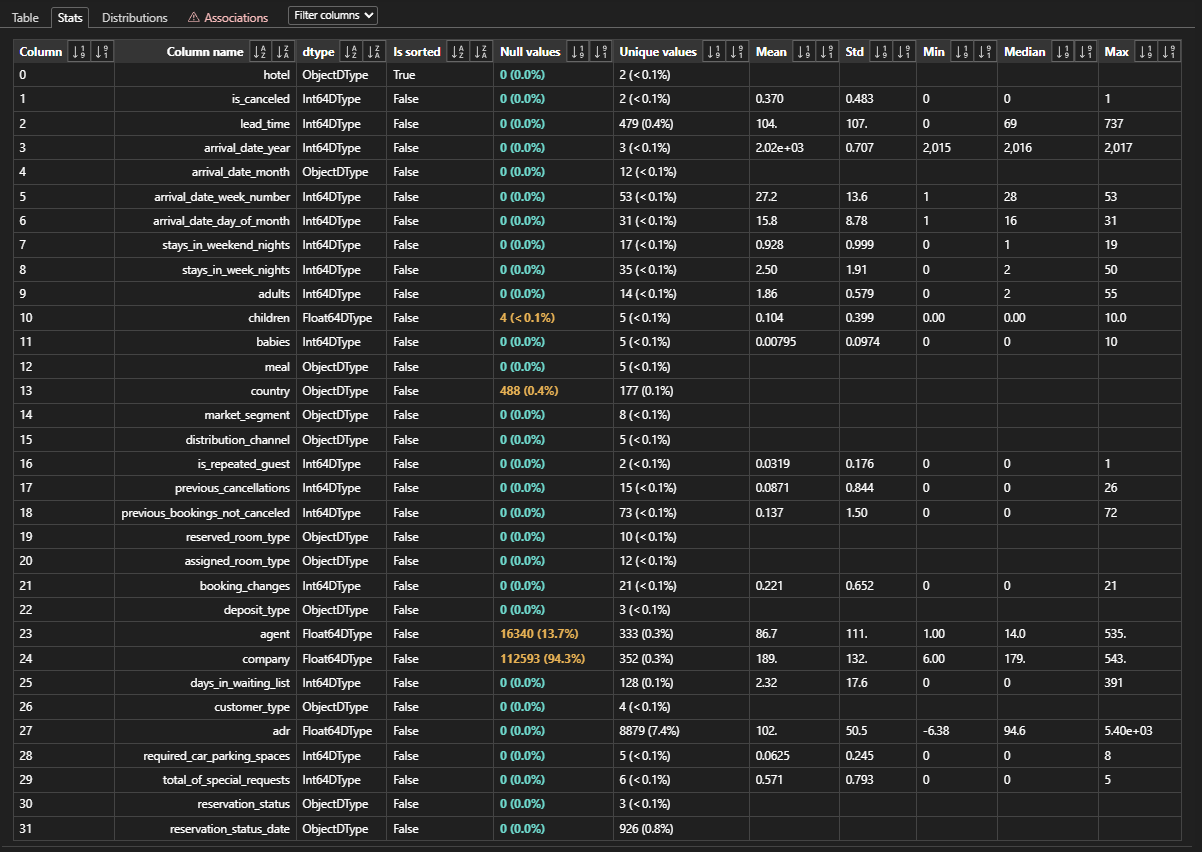

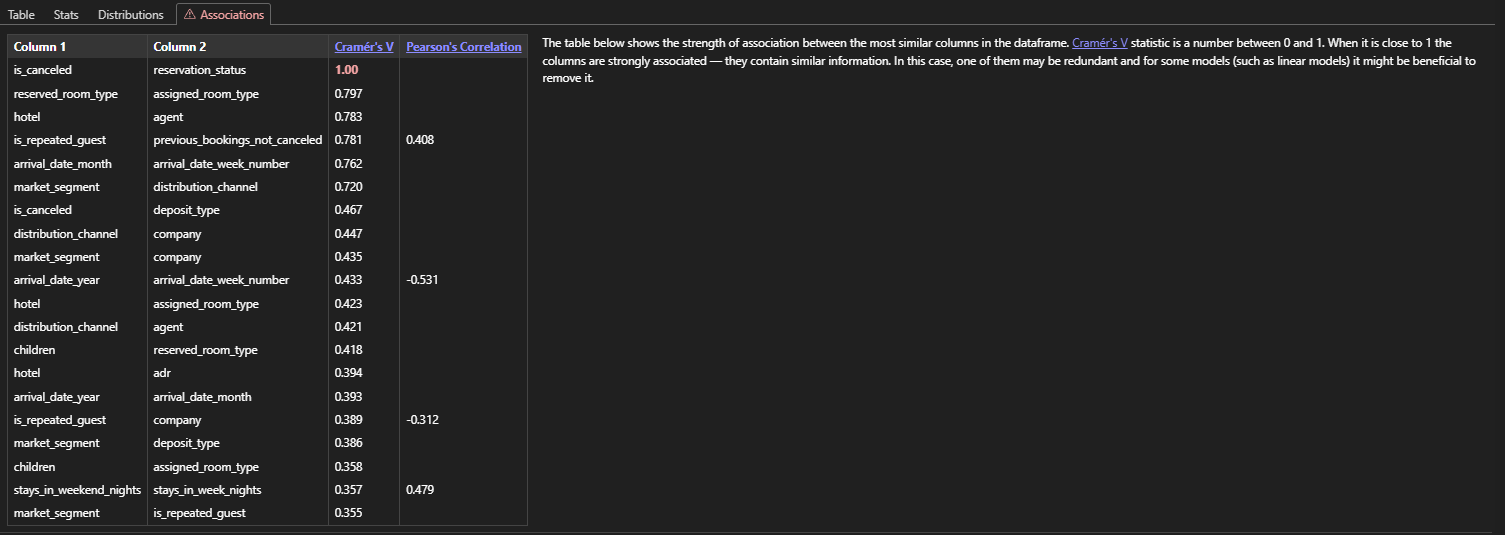

Some anomalies in the dataset is detected:
- Several missing values in the "children", "country", "agent", and "company" columns
- 1 to 1 association between "is_cancelled" (target) with "reservation_status" (feature); logical as one explains the other

##  4.1 Identifying Missing Value

In [13]:
listItem = []
for col in df_eda.columns :
    listItem.append([col, df_eda[col].dtype, df_eda[col].isna().sum(), round((df_eda[col].isna().sum()/len(df_eda[col])) * 100,2),
                    df_eda[col].nunique(), list(df_eda[col].drop_duplicates().sample(2).values)])

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,hotel,object,0,0.00,2,"[Resort Hotel, City Hotel]"
1,is_canceled,int64,0,0.00,2,"[0, 1]"
2,lead_time,int64,0,0.00,479,"[524, 100]"
3,arrival_date_year,int64,0,0.00,3,"[2016, 2017]"
4,arrival_date_month,object,0,0.00,12,"[April, November]"
5,arrival_date_week_number,int64,0,0.00,53,"[21, 51]"
6,arrival_date_day_of_month,int64,0,0.00,31,"[26, 6]"
7,stays_in_weekend_nights,int64,0,0.00,17,"[0, 12]"
8,stays_in_week_nights,int64,0,0.00,35,"[42, 40]"
9,adults,int64,0,0.00,14,"[3, 26]"


### Missing Value Insights

After checking for missing values in the dataset, we observed the following patterns:

- **`children`**: Only a few records are missing. Since the majority of values are 0 or positive integers, these missing entries are likely data entry issues. We can impute them with 0 or the most frequent value without losing much information.

- **`country`**: A small portion of records lack country information. Although the percentage is very low, it limits geographic-based analysis. For modeling, it’s reasonable to assign these records to a special category such as `"Unknown"`.

- **`agent`** and **`company`**: These columns contain a high proportion of missing values. This makes sense because not every booking is made via a travel agent or a company. The absence here is meaningful rather than an error, so replacing missing values with `"No Agent"` or `"No Company"` would preserve the information.

- **Other columns**: Most other features are complete with no missing values, which indicates relatively good data quality.

**Overall Insight:**  
The dataset is fairly clean, with missing values concentrated only in a few specific columns. These gaps can be handled using simple imputation or categorical grouping, ensuring that no significant information is lost for analysis or modeling.


In [14]:
# Handling Missing Values in hotel_bookings.csv

# Fill missing values using dictionary format
df_eda.fillna({
    'children': 0,
    'country': 'Unknown',
    'agent': 0,
    'company': 0
}, inplace=True)

let's recheck the dataframe information

In [15]:
listItem = []
for col in df.columns :
    listItem.append([col, df_eda[col].dtype, df_eda[col].isna().sum(), round((df_eda[col].isna().sum()/len(df_eda[col])) * 100,2),
                    df_eda[col].nunique(), list(df_eda[col].drop_duplicates().sample(2).values)])

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,hotel,object,0,0.0,2,"[City Hotel, Resort Hotel]"
1,is_canceled,int64,0,0.0,2,"[0, 1]"
2,lead_time,int64,0,0.0,479,"[350, 100]"
3,arrival_date_year,int64,0,0.0,3,"[2015, 2017]"
4,arrival_date_month,object,0,0.0,12,"[October, June]"
5,arrival_date_week_number,int64,0,0.0,53,"[8, 44]"
6,arrival_date_day_of_month,int64,0,0.0,31,"[10, 31]"
7,stays_in_weekend_nights,int64,0,0.0,17,"[4, 1]"
8,stays_in_week_nights,int64,0,0.0,35,"[25, 32]"
9,adults,int64,0,0.0,14,"[50, 2]"


now we've changed the missing value in
- `children` to 0
- `country` to 'Unknown'
- `agent` and `company` to 0
---

## 4.2 Identifying Anomalies Values

### 4.2.1 No Guests in Booking

There are some interesting find over the initial sample that needs to be taken care of

In [16]:
no_guest = df_eda['adults'] + df_eda['children'] + df_eda['babies']
no_guest = no_guest[no_guest == 0]
no_guest.count()

180

So we find that there are actually some booking in which no occupants are recorded. This is odd and not really explainable. With the insignificant amount recorded, we can safely remove these rows. Though it might be beneficial to see if there's clearer anomalies in their rows to fully justify the removals.

In [17]:
df_eda.loc[no_guest.index]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0.0,174.0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0.0,174.0,0,Transient,0.00,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,0.0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,0.0,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,June,26,27,0,3,0,0.0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,7.0,0.0,0,Transient,100.80,0,0,Check-Out,2017-06-30
115091,City Hotel,0,1,2017,June,26,30,0,1,0,0.0,0,SC,PRT,Complementary,Direct,0,0,0,E,K,0,No Deposit,0.0,0.0,0,Transient,0.00,1,1,Check-Out,2017-07-01
116251,City Hotel,0,44,2017,July,28,15,1,1,0,0.0,0,SC,SWE,Online TA,TA/TO,0,0,0,A,K,2,No Deposit,425.0,0.0,0,Transient,73.80,0,0,Check-Out,2017-07-17
116534,City Hotel,0,2,2017,July,28,15,2,5,0,0.0,0,SC,RUS,Online TA,TA/TO,0,0,0,A,K,1,No Deposit,9.0,0.0,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22


As can be seen from the table, there are several additional anomalies such as 0 ADR (signifying non arrival). Paired with the insignificant amount of rows as well as its possible distortion to the analysis if left alone, we can safely remove them after all.

In [18]:
# Remove rows where the total number of guests is zero
df_eda = df_eda[df_eda[["adults", "children", "babies"]].sum(axis=1) != 0]

# Check again
no_guest = df_eda['adults'] + df_eda['children'] + df_eda['babies']
no_guest = no_guest[no_guest == 0]
no_guest.count()

0

### 4.2.2 Outliers in ADR

In the earlier sections, there are some spotting of a negative value and extreme > 5000 in the ADR column. Let's see it again.

In [19]:
adr_negatives = df_eda.loc[df_eda['adr'] < 0]
adr_negatives

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,0.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [20]:
adr_extremes = df_eda.loc[df_eda['adr'] > 1000]
adr_extremes

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,12.0,0.0,0,Transient,5400.0,0,0,Canceled,2016-02-19


There is exactly one row in which the ADR is at a negative value and also one row where the ADR is at an extreme value (> 1000), we can safely remove thess since hotels won't pay for guests to stay and the highly abnormal ADR value. The singular rows are also too insignificant too affect the dataset, so removing it is okay. Now let's handle the extreme outliers.

In [21]:
df_eda = df_eda[(df_eda["adr"] >= 0) & (df_eda["adr"] <= 1000)]

## 4.3 Identifying Duplicated Values

In [22]:
# Exact Duplicate
if df_eda.duplicated().any():
    print("Duplicate rows found.")
    print("Total duplicate rows:", df_eda.duplicated().sum())
    print("Persentase Duplicate Row", round((df_eda.duplicated().sum()/len(df_eda))*100,2),"%")
    duplicated_row = df_eda[df_eda.duplicated(keep=False)]
else:
    print("No duplicate rows found.")

Duplicate rows found.
Total duplicate rows: 31980
Persentase Duplicate Row 26.83 %


### Duplicate Rows Insight

During the data quality check, we identified **31,994 duplicate rows** in the dataset as it is **26.8 %** from overall dataset.  
This represents a significant portion of the data, and keeping these duplicates may bias the analysis or the model training by over-representing certain booking records.

**Possible causes:**
- Multiple system entries of the same booking.  
- Data export or logging errors that caused repeated rows.  
- Genuine duplicates if the same customer made identical bookings (though this is less likely at such scale).  

**Impact on analysis:**
- If not removed, duplicates could distort feature distributions (e.g., overestimating cancellations, customer behavior, or booking channel trends).  
- Machine learning models might learn from repeated information, reducing their ability to generalize.

**Note:**
- The duplicates are the exact same for the whole row, with back-to-back order in the index.
- These are **NOT** functional duplicates as in it might be useful to learn customers' characters.
- Even when the customer id is removed, the exact duplications in order implicates multiple entries for the same booking.

**Next step:**
- Remove exact duplicates to ensure each row represents a unique booking. This will give us a cleaner dataset and avoid artificial inflation of certain patterns.


In [23]:
# Remove exact duplicates
df_eda = df_eda.drop_duplicates().reset_index(drop=True)

# Recheck exact duplicates
if df_eda.duplicated().any():
    print("Duplicate rows found.")
    print("Total duplicate rows:", df_eda.duplicated().sum())
    print("Persentase Duplicate Row", round((df_eda.duplicated().sum()/len(df_eda))*100,2),"%")
    duplicated_row = df_eda[df_eda.duplicated(keep=False)]
else:
    print("No duplicate rows found.")

No duplicate rows found.


Now, let's recheck the dataset if there's still any duplicates. then the target's distrivtuion ("is_cancelled").

In [24]:
# Exact Duplicate
if df_eda.duplicated().any():
    print("Duplicate rows found.")
    print("Total duplicate rows:", df_eda.duplicated().sum())
    print("Persentase Duplicate Row", round((df_eda.duplicated().sum()/len(df_eda))*100,2),"%")
    duplicated_row = df_eda[df_eda.duplicated(keep=False)]
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [25]:
# Target distribution after adjustment
df_eda['is_canceled'].value_counts(normalize=True) * 100

is_canceled
0    72.476728
1    27.523272
Name: proportion, dtype: float64

It seems that the non-cancellation increases by substantial amount, making the dataset determinedly unbalanced with 73% non-cancellation and 27% cancellation.

## 4.4 Data Enrichment

### 4.4.1 Calculating Total Stay Duration

As a booking's duration is separated into weekdays and weekends, it'll be helpful for initial analysis to extract these separated features into new ones. Some of the enrichment would be to create stay duration and exact time of stay.

In [26]:
### Duration of Stay (new feature!)
df_eda['stay_duration'] = df_eda['stays_in_weekend_nights'] + df_eda['stays_in_week_nights']
df_eda.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,stay_duration
74946,City Hotel,0,2,2017,January,3,18,0,1,1,0.0,0,BB,ESP,Groups,TA/TO,0,0,0,A,A,0,No Deposit,19.0,0.0,0,Transient-Party,75.00,0,0,Check-Out,2017-01-19,1
32486,Resort Hotel,0,178,2017,July,28,14,2,6,2,0.0,0,HB,ESP,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,0.0,0,Transient,167.85,0,1,Check-Out,2017-07-22,8
35718,City Hotel,0,135,2015,September,38,14,1,2,2,0.0,0,BB,CN,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,6.0,0.0,0,Transient-Party,90.00,0,0,Check-Out,2015-09-17,3
51238,City Hotel,1,12,2017,July,28,15,1,1,1,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,0.0,0,Transient,129.00,0,1,Canceled,2017-07-10,2
8867,Resort Hotel,1,22,2017,June,22,3,0,1,2,0.0,0,BB,ESP,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,0.0,0,Transient,135.00,0,1,Canceled,2017-05-23,1


With this we can calculate for the exact nights a booking lasted.

### 4.4.2 Extracting Time-Date Feature

The dataset already provides separated booking arrival date, but no exact one that compiles all of it. This will be the feature to do that.

In [27]:
df_eda["arrival_date"] = pd.to_datetime(df_eda["arrival_date_year"].astype(str) + '-' + df_eda["arrival_date_month"].astype(str) + '-' + df_eda["arrival_date_day_of_month"].astype(str))

### 4.4.3 Total Guests

In [28]:
df_eda['total_guests'] = df_eda['adults'] + df_eda['children'] + df_eda['babies']

## 4.6 Delete Unnecessary Columns 

Since it's been known from the previous table report that "reservation status" has a 1 by 1 colinearity with the target "is_cancelled", we must drop it as to make the model credible.

In [29]:
# Dropping reservation_status
df_eda.drop(columns=['reservation_status', 'reservation_status_date', "agent", "company"], inplace=True)

## 4.7 Recasting data types

This will be a minor modification, but might go a long way to preserve memory in the long run.

In [31]:
# Cast each columns to its according data type
df_eda['hotel'] = df_eda['hotel'].astype("category")
df_eda['arrival_date_year'] = df_eda['arrival_date_year'].astype("category")
df_eda['arrival_date_month'] = df_eda['arrival_date_month'].astype("category")
df_eda['arrival_date_week_number'] = df_eda['arrival_date_week_number'].astype("category")
df_eda['arrival_date_day_of_month'] = df_eda['arrival_date_day_of_month'].astype("category")
df_eda['children'] = df_eda['children'].astype(int)
df_eda['meal'] = df_eda['meal'].astype("category")
df_eda['country'] = df_eda['country'].astype("category")
df_eda['market_segment'] = df_eda['market_segment'].astype("category")
df_eda['distribution_channel'] = df_eda['distribution_channel'].astype("category")
df_eda['is_repeated_guest'] = df_eda['is_repeated_guest'].astype("category")
df_eda['reserved_room_type'] = df_eda['reserved_room_type'].astype("category")
df_eda['assigned_room_type'] = df_eda['assigned_room_type'].astype("category")
df_eda['deposit_type'] = df_eda['deposit_type'].astype("category")
df_eda['customer_type'] = df_eda['customer_type'].astype("category")

Cool, let's see the dataset again now.

In [37]:
df_eda['customer_type'].value_counts()

customer_type
Transient          71861
Transient-Party    11691
Contract            3135
Group                541
Name: count, dtype: int64

In [180]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87228 entries, 0 to 87227
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87228 non-null  category      
 1   is_canceled                     87228 non-null  int64         
 2   lead_time                       87228 non-null  int64         
 3   arrival_date_year               87228 non-null  category      
 4   arrival_date_month              87228 non-null  category      
 5   arrival_date_week_number        87228 non-null  category      
 6   arrival_date_day_of_month       87228 non-null  category      
 7   stays_in_weekend_nights         87228 non-null  int64         
 8   stays_in_week_nights            87228 non-null  int64         
 9   adults                          87228 non-null  int64         
 10  children                        87228 non-null  int32         
 11  ba

## 4.8 Feature Analysis

## 4.9 Feature Correlation

Let's see from the overall correlation in the TableReport, then follow up from there.

In [181]:
report = TableReport(df_eda, max_plot_columns=32, max_association_columns=32)
report

Processing column  31 / 31


,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


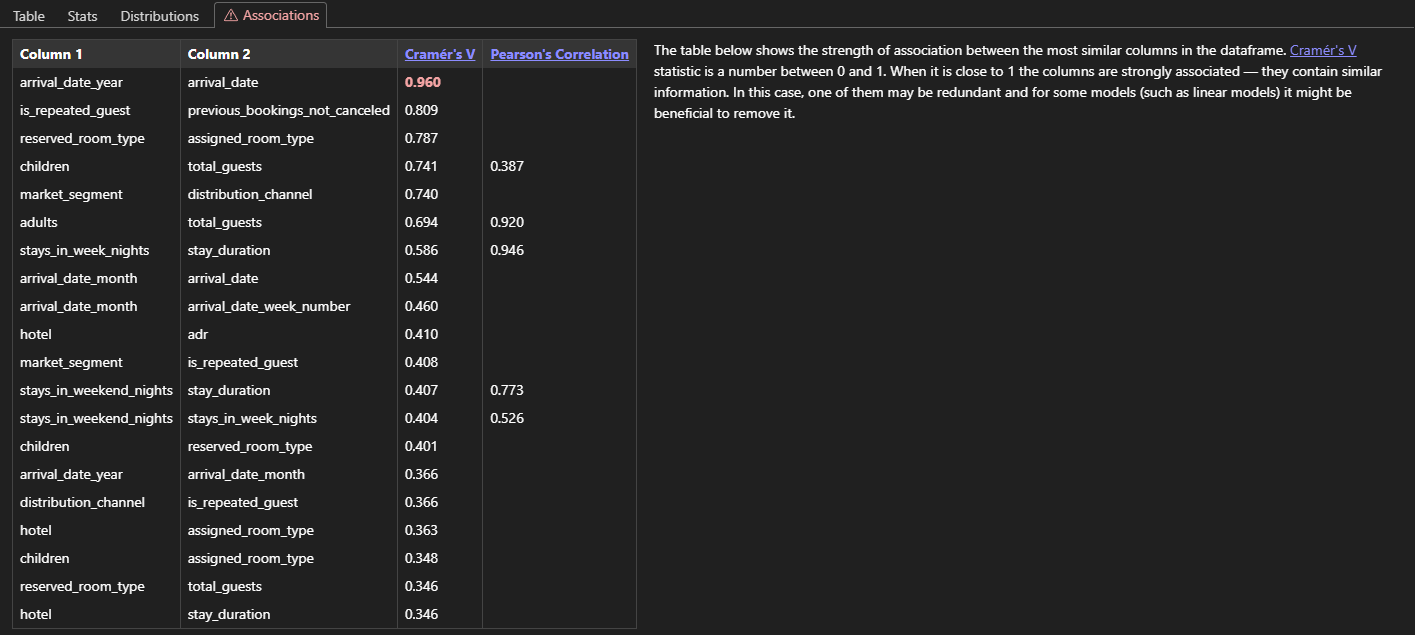

We can see from the table that there are several high correlation between features. Let's try uncover them one by one:
- is_repeated_guest and previous_bookings_not_canceled are logical to be aligned due to the nature of customers' loyalty already proven.
- reserved_room_type and assigned_room_type are also straightforward with only force majeure or on-site requests having big factor in possible changes.
- market_segment and distribution_channel is an interesting one, we'll return to it later.
- children and adults correlating to the total_guests is a given due to them basically a building block for the other feature. The same can be said for other enriched features such as stay_duration and arrival_date with each of their building block.

These will be a brief overview of each features correlations mentioned above:

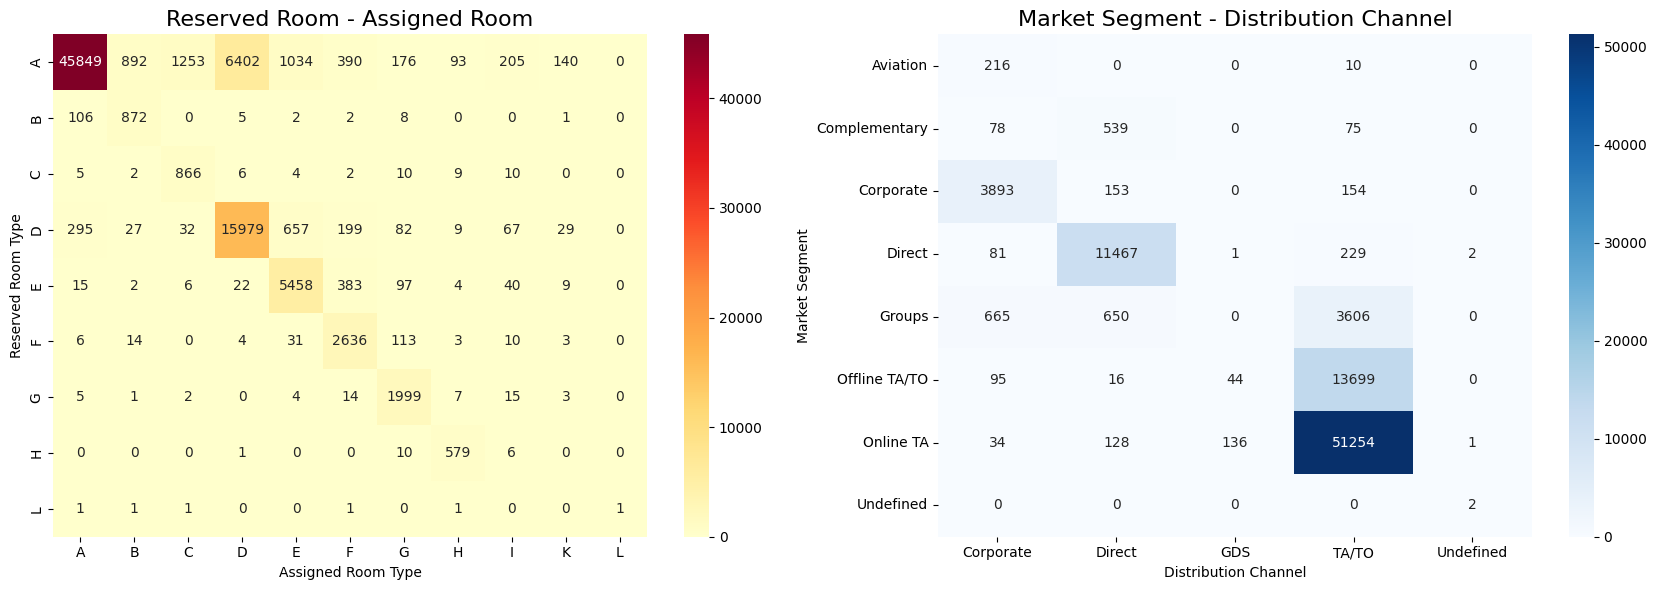

In [182]:
# Hetamap assignment
heat_reserved_assigned = pd.crosstab(df_eda["reserved_room_type"], df_eda["assigned_room_type"])
heat_segment_distribution = pd.crosstab(df_eda["market_segment"], df_eda["distribution_channel"])

# Heatmap rows and columns
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Room Correlation
sns.heatmap(heat_reserved_assigned, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Reserved Room - Assigned Room", fontsize=16)
axes[0].set_xlabel("Assigned Room Type")
axes[0].set_ylabel("Reserved Room Type")

# Market Distribution
sns.heatmap(heat_segment_distribution, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Market Segment - Distribution Channel", fontsize=16)
axes[1].set_xlabel("Distribution Channel")
axes[1].set_ylabel("Market Segment")

plt.tight_layout()
plt.show()


In [183]:
df_eda[["previous_bookings_not_canceled", "is_repeated_guest"]].corr()

,previous_bookings_not_canceled,is_repeated_guest
previous_bookings_not_canceled,1.000000,0.444333
is_repeated_guest,0.444333,1.000000


Several insights:
- As can be seen above, between reserved and assigned room type, there is a clear alignment from A-H room type that decreases in number nearing H. The only abnormality would be the A reserved and E assigned, showing the only out of place number. This also can be seen in the A reserved to B-K, signalling what might be hotels' policy in overbooked room. We can assume A is the most common booked type that overspills to other room types (looking at the assigned numbers) when hotels upgrade customers' booking in overbooked condition. This will be analyzed further in the analysis section.
- For the market_segment and distribution_channel there is no obvious abnormalities like in reserved-assigned room type, simply showing mostly 1:1 correlation to each type.
- For the previous_bookings_not_canceled and is_repeated_guest, it seems simple correlation function does not show any significant relation, though going by the TableReport's cramer score, it can be reasonably inferred some relations (though it is not crucial for analysis or model)
- For other obvious correlating features (stay_duration, total_guests, etc) it won't matter much as their usage is mainly for insight analysis and will be remove during model training.

# Section 5: Data Analysis

In this section we'll dissect many of the features relation to the target using experimental visualization over them. We'll try to get as many insights that might help along the way in making an ML model later on, as well as give the marketing and management team some factors of consideration when reviewing their policies or programs.

### 5.1 Deposit Type Impact upon Cancellation Rate

Deposit type matter a lot in common sense for a customer's decision whether or not to cancel a booking. We must make sure it is the same case within our dataset by at first comparing the real number, then in percentage to see the weights.

In [184]:
depo_raw = df_eda['deposit_type'].value_counts()
depo_percentage = df_eda['deposit_type'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Raw': depo_raw, 'Percent': depo_percentage.round(2)})
summary

,Raw,Percent
deposit_type,,
No Deposit,86084,98.69
Non Refund,1037,1.19
Refundable,107,0.12


As can be seen, the deposit type is dominating hotels' policies by very significant margin in 98%. compared to non-refund in 1% and refundable in 0.1%. This might have an impact to cancellation rate which we'll see next.

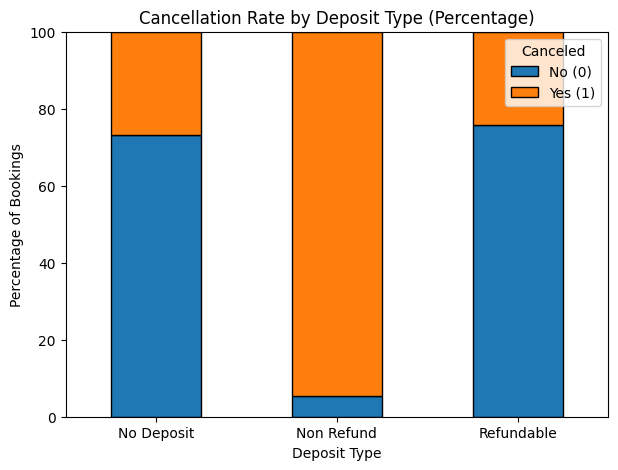

In [185]:
# Setting the colour palette
colourr = {
    0: '#1f77b4',
    1: '#ff7f0e'
}

colourr_str = {
    '0': '#1f77b4',
    '1': '#ff7f0e'
}

# group and normalize to percentages
counts = df_eda.groupby(['deposit_type','is_canceled']).size().unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100  # convert to %

# stacked percentage bar chart
percentages.plot(kind='bar', stacked=True, color=[colourr[0],colourr[1]], edgecolor='black', figsize=(7,5))

plt.title("Cancellation Rate by Deposit Type (Percentage)")
plt.xlabel("Deposit Type")
plt.ylabel("Percentage of Bookings")
plt.legend(title="Canceled", labels=['No (0)','Yes (1)'])
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

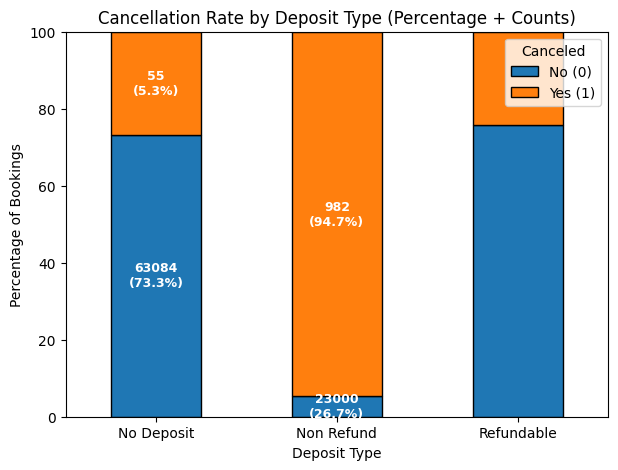

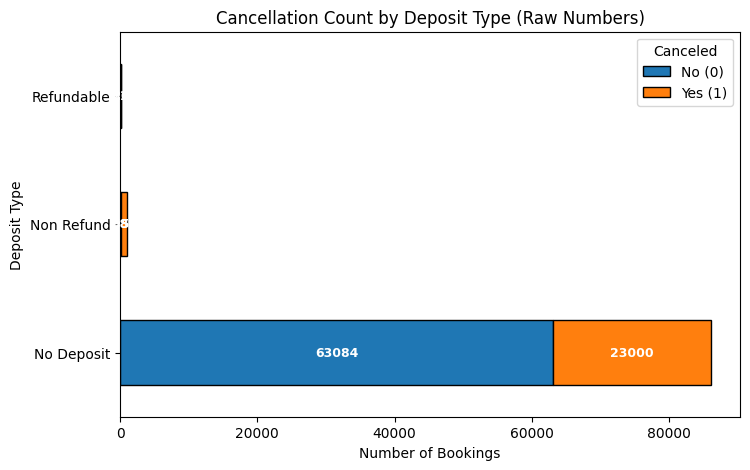

In [186]:
# Setting the colour palette
colourr = {
    0: '#1f77b4',
    1: '#ff7f0e'
}

# group and normalize to percentages
counts = df_eda.groupby(['deposit_type','is_canceled']).size().unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100  # convert to %

# plot
ax = percentages.plot(
    kind='bar', stacked=True,
    color=[colourr[0], colourr[1]],
    edgecolor='black', figsize=(7,5)
)

plt.title("Cancellation Rate by Deposit Type (Percentage + Counts)")
plt.xlabel("Deposit Type")
plt.ylabel("Percentage of Bookings")
plt.legend(title="Canceled", labels=['No (0)','Yes (1)'])
plt.ylim(0, 100)
plt.xticks(rotation=0)

# Adding labels to the chart
for container, deposit in zip(ax.containers, counts.index):
    for bar, (cat, val) in zip(container, counts.loc[deposit].items()):
        height = bar.get_height()
        if height > 0:  # skip zero-height bars
            percent_val = percentages.loc[deposit, cat]
            raw_val = val
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{raw_val}\n({percent_val:.1f}%)",
                ha='center', va='center', fontsize=9, color='white', fontweight='bold'
            )

# Showing real number in chart
counts = df_eda.groupby(['deposit_type','is_canceled']).size().unstack(fill_value=0)
ax = counts.plot(
    kind='barh', stacked=True,
    color=[colourr[0], colourr[1]],
    edgecolor='black', figsize=(8,5)
)

plt.title("Cancellation Count by Deposit Type (Raw Numbers)")
plt.xlabel("Number of Bookings")
plt.ylabel("Deposit Type")
plt.legend(title="Canceled", labels=['No (0)','Yes (1)'])
plt.xticks(rotation=0)

# annotate bars with raw counts
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        if width > 0:
            ax.text(
                bar.get_x() + width/2,  # center horizontally
                bar.get_y() + bar.get_height()/2,  # center vertically
                f"{int(width)}",
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )

plt.show()


As no deposit would dwarf other types in the bar plot, we can better see the comparison using their percentage point. An anomaly to common sense appears in the non-refund type as its cancellation rate is so much higher than the other two types, standing at more than 90% compared to no deposit and refundable that hovers around 30%.

In [187]:
df_eda.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).sort_index(ascending=True)

deposit_type  is_canceled
No Deposit    0              0.732819
              1              0.267181
Non Refund    0              0.053038
              1              0.946962
Refundable    0              0.757009
              1              0.242991
Name: proportion, dtype: float64

An important context for this phenomenon would be Portugal's visa requirement of a hotel booking for tourists that is being exploited by Tourism Agency (TA). This would mean TA purposefully booked fictive hotel orders where the conclusive end is a cancellation. This is a distortion of the dataset from outside of the collection and analysis scope, thus making it expendable. We can also see this as a way for hotels' to mitigate such orders by putting it into the non-deposit type, shelving costs by securing the initial payment. It is a minor problem since this type of deposit only make around 1% of the whole dataset. But it might be interesting to see if it's true TA are responsible for this distortion, let's see.

In [188]:
TA_check = df_eda.loc[df_eda['deposit_type'] == 'No Deposit'].groupby('is_canceled')['distribution_channel'].value_counts(normalize=True).unstack(fill_value=0) * 100
TA_check

distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
is_canceled,,,,,
0,6.957390,17.378416,0.229852,75.432756,0.001585
1,2.521739,8.156522,0.156522,89.147826,0.017391


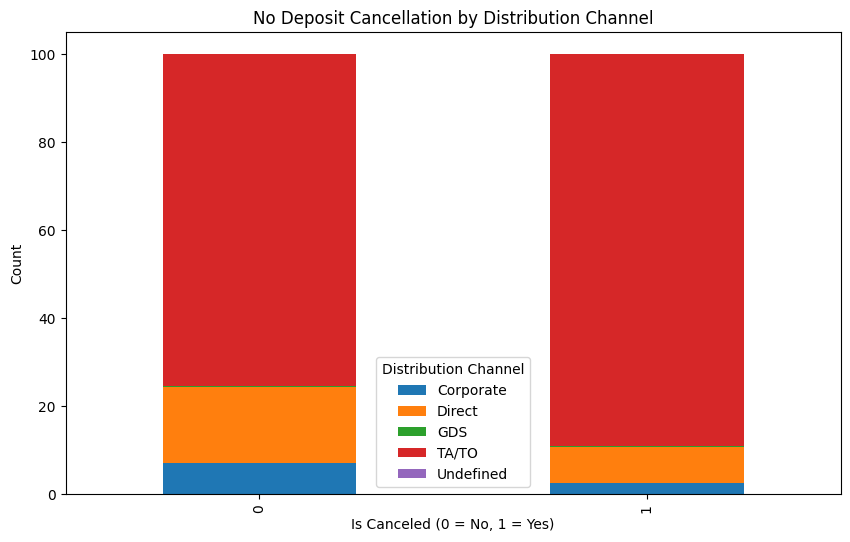

distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
is_canceled,,,,,
0,6.957390,17.378416,0.229852,75.432756,0.001585
1,2.521739,8.156522,0.156522,89.147826,0.017391


In [189]:
ax = TA_check.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("No Deposit Cancellation by Distribution Channel")
plt.xlabel("Is Canceled (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Distribution Channel")
plt.show()

TA_check = df_eda.loc[df_eda['deposit_type'] == 'No Deposit'].groupby('is_canceled')['distribution_channel'].value_counts(normalize=True).unstack(fill_value=0) * 100
TA_check

It doesn't show decisively that TA/TO is responsible mainly since the distribution is almost alike. But it can be seen from proportion alone, that in the canceled section, TA/TO gained more number in comparison to the not canceled section. The assumption for the Portugal's visa exploitation distortion can be concluded as reasonable then.

### 5.2 Lead Time's Window of Cancellation

The duration from a customer's booking to the time of the date the booking is for can be an indication of canceling factor. For example it can be assumed that someone booking a year away might have more window of opportunities to consider cancelling their booking. It is of course still an assumption which can be dispelled in the analysis below.

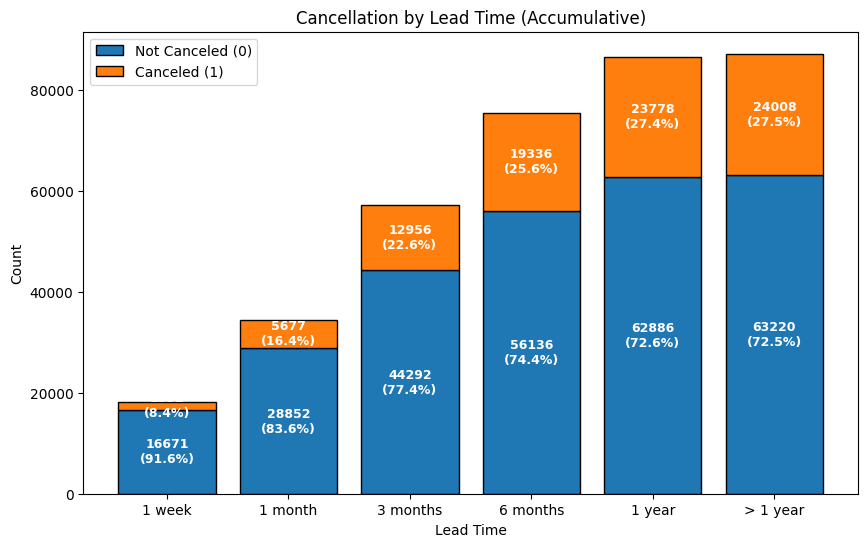

In [190]:
# Making the bins
lead_bins = [7, 30, 90, 180, 365, df_eda["lead_time"].max()]
bin_labels = ['1 week', '1 month', '3 months', '6 months', '1 year', '> 1 year']

# Calculating the cumulative counts
not_canceled = [((df_eda["lead_time"] <= b) & (df_eda["is_canceled"] == 0)).sum() for b in lead_bins]
canceled     = [((df_eda["lead_time"] <= b) & (df_eda["is_canceled"] == 1)).sum() for b in lead_bins]

# Total for percentages
totals = [n + c for n, c in zip(not_canceled, canceled)]

# Plotting
fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(bin_labels, not_canceled, label="Not Canceled (0)", color=colourr[0], edgecolor='black')
bars2 = ax.bar(bin_labels, canceled, bottom=not_canceled, label="Canceled (1)", color=colourr[1], edgecolor='black')

# Adding labels
for i, (bar1, bar2, n, c, total) in enumerate(zip(bars1, bars2, not_canceled, canceled, totals)):
    # Not canceled label
    if n > 0:
        ax.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height()/2,
                f"{n}\n({n/total*100:.1f}%)", 
                ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    # Canceled label
    if c > 0:
        ax.text(bar2.get_x() + bar2.get_width()/2, bar1.get_height() + bar2.get_height()/2,
                f"{c}\n({c/total*100:.1f}%)", 
                ha='center', va='center', color='white', fontsize=9, fontweight='bold')

ax.set_xlabel("Lead Time")
ax.set_ylabel("Count")
ax.set_title("Cancellation by Lead Time (Accumulative)")
ax.legend()

plt.show()


As is shown in the bar plot, a lead time somewhere less than a week has the least cancellation rate, perhaps considering the short duration between booking and stay time making the decision a sure fire one. In comparison to less than a month, less than 3 months, and within a year, the cancellation rate keep climbing along with the wider window of canceling.

### 5.3 ADR Range Relations to Canceled Guests

We can assume that ADR range would have some impact to customers' relation to cancelling a booking. We can try testing that assumption by making a comparison between customers who cancelled and didn't cancel, then putting it side by side to check if there's any noticable difference.

In [191]:
low, high = df_eda['adr'].quantile([0.01, 0.99])
df_adr = df_eda.copy()
df_adr['adr_capped'] = df_eda['adr'].clip(lower=low, upper=high)
df_adr['adr_capped']

0          0.00
1          0.00
2         75.00
3         75.00
4         98.00
          ...  
87223     96.14
87224    225.43
87225    157.71
87226    104.40
87227    151.20
Name: adr_capped, Length: 87228, dtype: float64

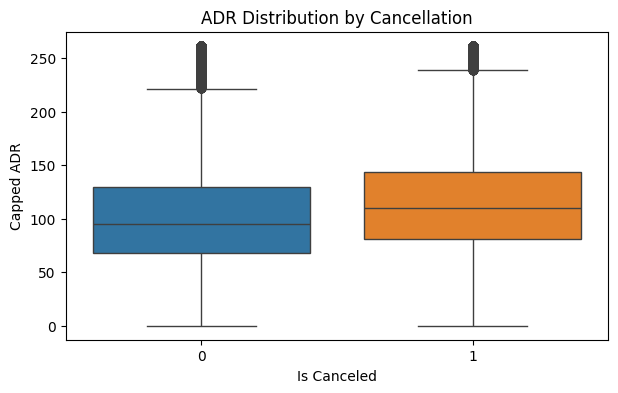

In [192]:
plt.figure(figsize=(7,4))
sns.boxplot(x='is_canceled', y='adr_capped', data=df_adr, palette=colourr_str)
plt.title('ADR Distribution by Cancellation')
plt.xlabel('Is Canceled')
plt.ylabel('Capped ADR')
plt.show()

As can be seen in the boxx plot above, there are no noticeable difference between the two group. They even have significant overlapping at around USD 100 ADR level, the canceling group slightly ahead. What might need further analysis are the outliers that can be seen crowding the end point of the plot, making it rather important for a more decisive conclusion.

### 5.4 Arrival Date and Seasonal Bookings Analysis

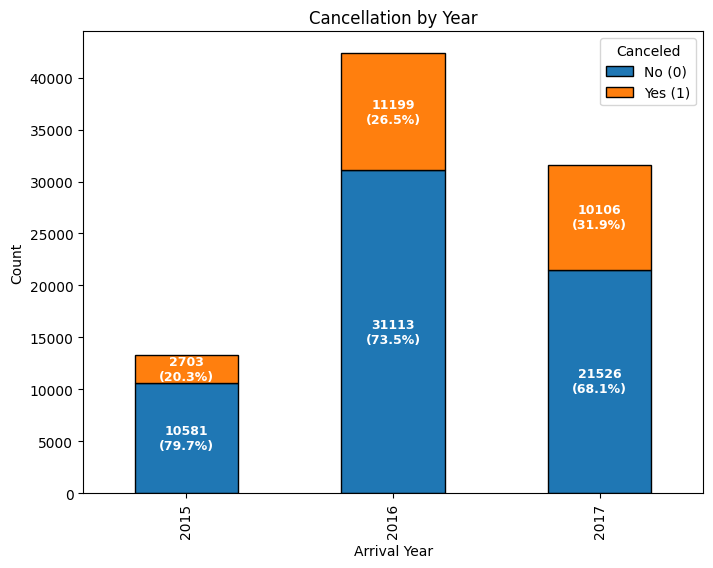

In [193]:
# Group by year and cancellation status
cancel_by_year = df_eda.groupby(["arrival_date_year", "is_canceled"]).size().unstack(fill_value=0)

# Plot
ax = cancel_by_year.plot(kind="bar", stacked=True, edgecolor='black', figsize=(8,6),
                         color=[colourr[0], colourr[1]])

# Add labels inside the bars
for idx, (not_canceled, canceled) in enumerate(zip(cancel_by_year[0], cancel_by_year[1])):
    total = not_canceled + canceled
    
    # Not canceled
    if not_canceled > 0:
        ax.text(idx, not_canceled/2,
                f"{not_canceled}\n({not_canceled/total*100:.1f}%)",
                ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    
    # Canceled
    if canceled > 0:
        ax.text(idx, not_canceled + canceled/2,
                f"{canceled}\n({canceled/total*100:.1f}%)",
                ha="center", va="center", color="white", fontsize=9, fontweight="bold")

# Labels & title
ax.set_xlabel("Arrival Year")
ax.set_ylabel("Count")
ax.set_title("Cancellation by Year")
ax.legend(title="Canceled", labels=['No (0)','Yes (1)'])

plt.show()


The dataset collection time explains why 2016 has the most amount of data compared to 2015 and 2017. It's not that hotels are more booked in 2016, rather that the only full year collecting was done in 2016. In 2015 the collecting started at August, while in 2017 it ended in July. This does mean that comparing between second half of a year (2015) has less cancellation than first half of a year (2017), though the total amount of booking might also explain the discrepancy.

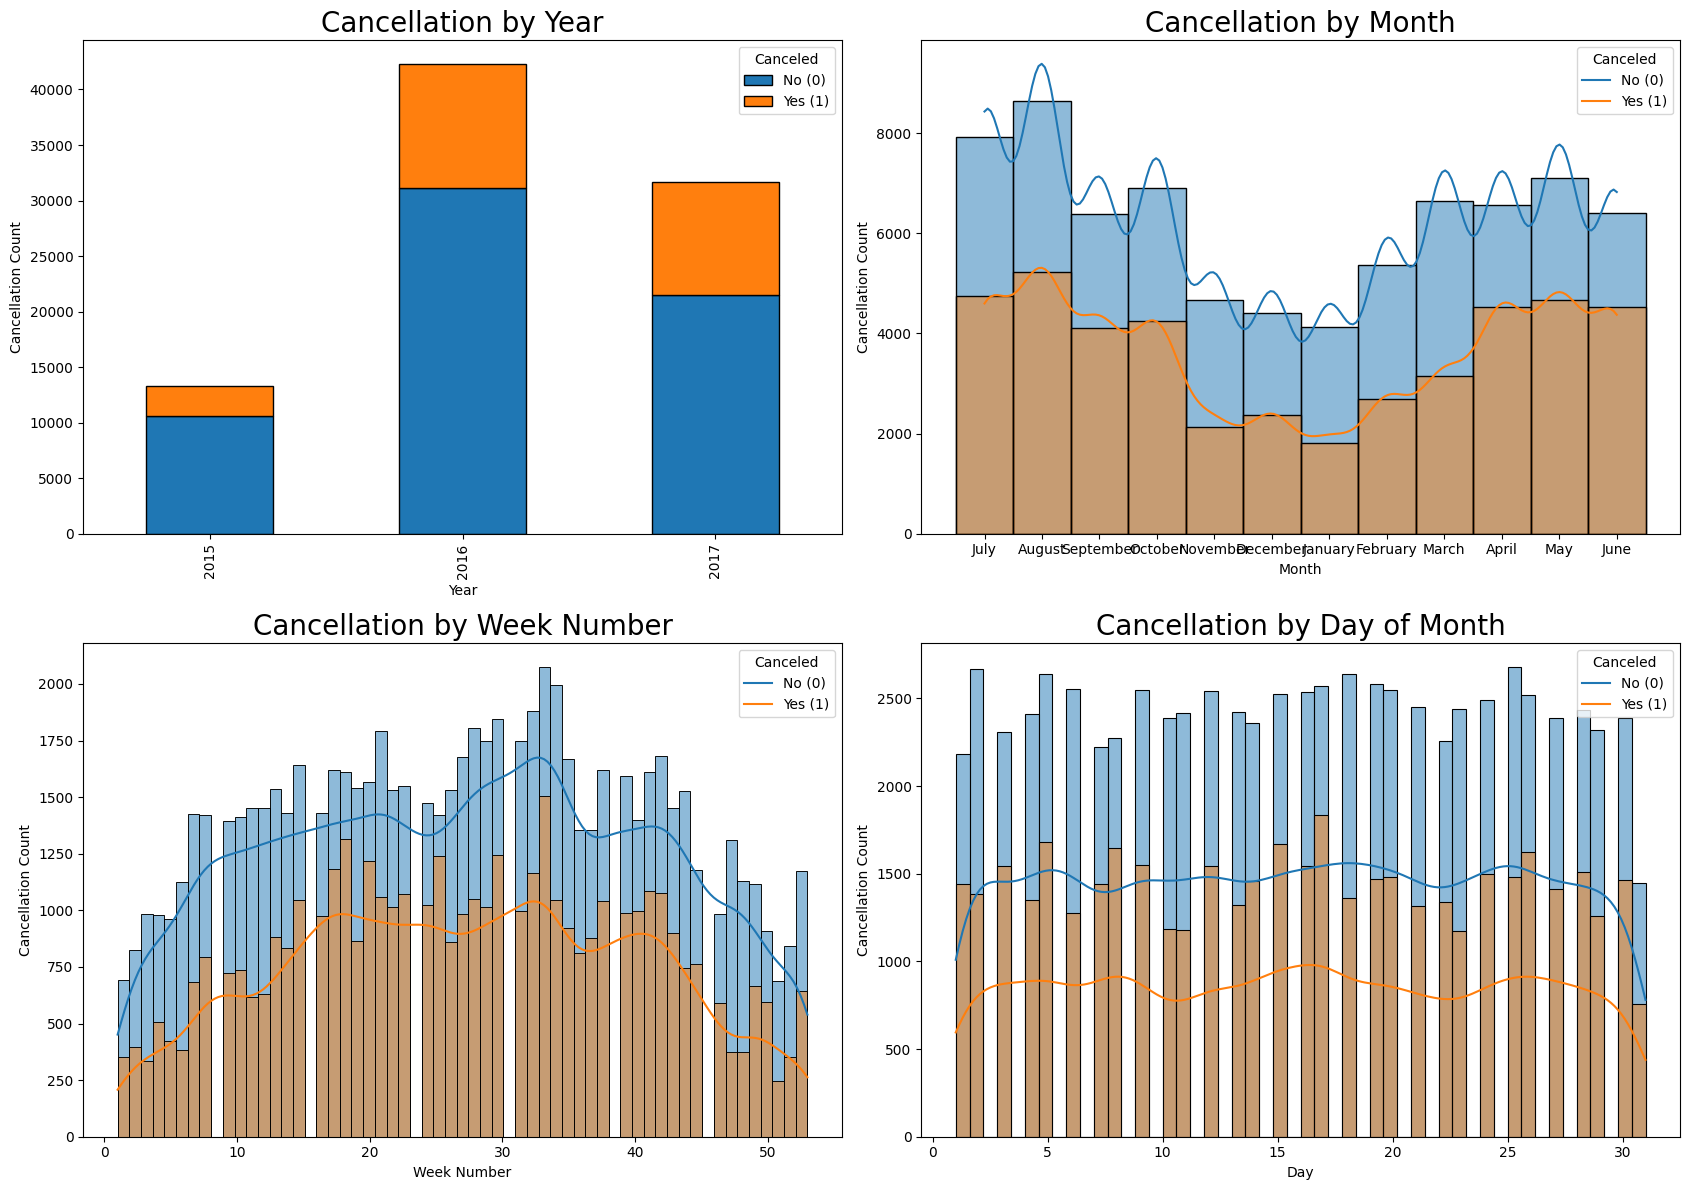

In [194]:
# Group by lead_time_bin and is_canceled, then plot
cancel_by_year = df_eda.groupby(["arrival_date_year", "is_canceled"]).size().unstack(fill_value=0)

# Make figure (modified wow)
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

# Barplot of Year
cancel_by_year.plot(kind="bar", stacked=True, ax=axes[0,0], color=colourr, edgecolor='black')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Cancellation Count')
axes[0,0].set_title('Cancellation by Year', fontsize=20)
axes[0,0].legend(title="Canceled", labels=['No (0)','Yes (1)'])

# Histogram month
sns.histplot(data=df, x='arrival_date_month', hue='is_canceled', hue_order=[1,0], kde=True, ax=axes[0,1], palette=colourr)
axes[0,1].set_title('Cancellation by Month', fontsize=20)
axes[0,1].legend(title="Canceled", labels=['No (0)','Yes (1)'])
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Cancellation Count')

# Histogram week number
sns.histplot(data=df, x='arrival_date_week_number', hue='is_canceled', hue_order=[1,0], kde=True, ax=axes[1,0], palette=colourr)
axes[1,0].set_title('Cancellation by Week Number', fontsize=20)
axes[1,0].legend(title="Canceled", labels=['No (0)','Yes (1)'])
axes[1,0].set_xlabel('Week Number')
axes[1,0].set_ylabel('Cancellation Count')

# Histogram day of month
sns.histplot(data=df, x='arrival_date_day_of_month', hue='is_canceled', hue_order=[1,0], kde=True, ax=axes[1,1], palette=colourr)
axes[1,1].set_title('Cancellation by Day of Month', fontsize=20)
axes[1,1].legend(title="Canceled", labels=['No (0)','Yes (1)'])
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Cancellation Count')

plt.tight_layout()
plt.show()

In this section's analysis, the aim is to see seasonal trend or swing in the bookings. For example in July and August, bookings are at record high, signifying the importance of summer holiday season to this hotels. We can infer from Portugal's location as one of the Mediterranean European country as a very crucial aspect to their tourism attraction, thus hotels' boom. In a reverse situation, winters and the Christmas and New Year holiday do not perform well in bookings number, showing the worst record from November-January. This is also well reflected in the 2015 and 2017 data where the data collection is done in the second semester (2015) and first semester (2017), showcasing stronger number in 2017.

### 5.5 Room Reservation-Assignment Overbooking Policy Insight

Text(70.72222222222221, 0.5, 'Reserved Room Type')

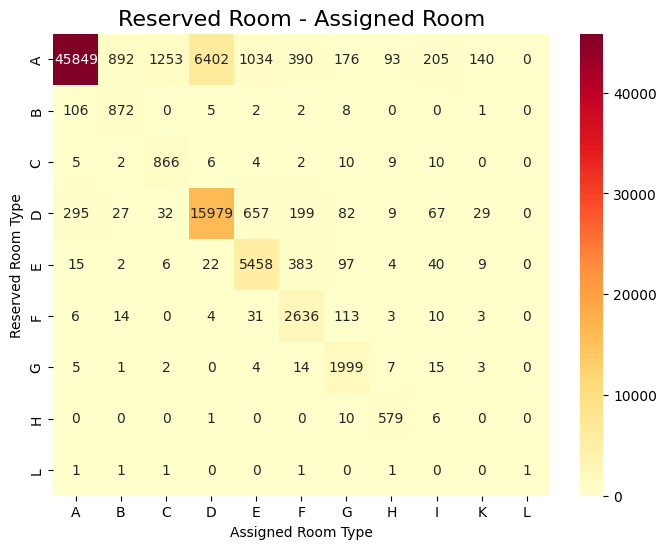

In [195]:
# Heatmap (single verison)
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(heat_reserved_assigned, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Reserved Room - Assigned Room", fontsize=16)
ax.set_xlabel("Assigned Room Type")
ax.set_ylabel("Reserved Room Type")

Back in the feature correlation section we mentioned a further analysis over this heatmap. What might be an interesting insight is how this heatmap proves and visualize clearly how hotels would use overbooking policy as part of their effort in curbing the loss from False Negative (empty room due to model's failure in predicting high-risk cancellation bookings). As has been briefly explained as well, we can see how room type A is the highest booked as it is the most reserved, followed by D, E, F, H, and G. We can see a following pattern from these rooms where in their rows, the assigned room for higher room type proceeds accordingly in number. For example row in room type A. There are substantial numbers of assigned room in room type B-K, which also follows for row in room type D with assigned room from E-K, and follows. These means hotels purposefully aim for overbooking in general, those bookings then over spilling into higher room types as a form of compensation from the hotel to the unlucky (or lucky) customers.

How do we know if it's a form of compensation? Easy enough, the room types that are used for bumper compliment are more expensive than the ones in the booking:

In [196]:
avg_adr_reserved = df_eda.groupby("reserved_room_type")["adr"].mean().reset_index()
avg_adr_reserved


,reserved_room_type,adr
0,A,92.374760
1,B,90.593604
2,C,160.737440
3,D,122.218799
4,E,126.134553
5,F,168.451323
6,G,176.900322
7,H,188.763993
8,L,124.666667


In the table there are consistencies and abnormalities, let's address all of them.
- Aligned with our expectations; A, D, E, F, G, and H all have ascending ADR, which means the overbooked policy assumption holds true (room type upgrade for overbooked customers)
- B, C, and L have abnormal nature compared to the other room types, with all of them showing lackluster number of bookings
- B is cheaper than A in average ADR, while C is almost as expensive as F, a room type several levels above it
- L only has one reservation in the whole 2 years of data collection, and singular assignment from other room type reservations
- We can assume then that B, C, and L are special room types with no particular recognizable pattern that can explain their uniqueness better
- It must be remembered that this dataset remove personal identifier, so perhaps this will be an inherent limitation, only solvable by getting the unmodified original dataset

In [197]:
# Prepare the data for comparison
df_eda["reserved_room_type"] = df_eda["reserved_room_type"].astype(str)
df_eda["assigned_room_type"] = df_eda["assigned_room_type"].astype(str)

# Comparing the correct assignment rate
total_per_reserved = df_eda.groupby("reserved_room_type")["assigned_room_type"].count()

correct_per_reserved = df_eda[df_eda["reserved_room_type"] == df_eda["assigned_room_type"]] \
    .groupby("reserved_room_type")["assigned_room_type"].count()

percentage_correct = (correct_per_reserved / total_per_reserved * 100).fillna(0).reset_index()
percentage_correct.columns = ["reserved_room_type", "correct_assignment_percentage"]

percentage_correct

,reserved_room_type,correct_assignment_percentage
0,A,81.243577
1,B,87.550201
2,C,94.748359
3,D,91.960175
4,E,90.424122
5,F,93.475177
6,G,97.512195
7,H,97.147651
8,L,16.666667


This is a nice supporting perspective that from all the room types, A has the worst correct assignment rate. L is at 17%, but it is a very strange one as well, so we can safely remove it from consideration.

# Section 6: Data Preparation And Feature Engineering

## 6.1 Initialization

We have cleaned and modified the dataset to df_eda. But, for model training compatibility, we need to remove and modify again the dataset to better suit the purpose. This means dropping, enriching, or other means necessary. We'll explain each justification below. We are still using df_eda, only to skip the remove duplicates process.

In [198]:
# Create a copy from df_eda
df_model = df_eda.copy()

In [199]:
# Drop problematic columns for modeling
df_model.drop(columns=['stay_duration', 'total_guests', 'arrival_date'], inplace=True)

Here we are dropping several columns immediately:
- stay_duration and total_guests will be used again, but needs to be addressed early due to clash in variable assignment if not handled
- arrival_date was only for EDA purposes, it doesn't bode well in model training, even containing high association with its building blocks like arrival_date_month, etc
- It is of note that all these features are the ones enriched in EDA, not inherently exist in the raw dataset

In [200]:
display(df_model.info(), df_model.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87228 entries, 0 to 87227
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           87228 non-null  category
 1   is_canceled                     87228 non-null  int64   
 2   lead_time                       87228 non-null  int64   
 3   arrival_date_year               87228 non-null  category
 4   arrival_date_month              87228 non-null  category
 5   arrival_date_week_number        87228 non-null  category
 6   arrival_date_day_of_month       87228 non-null  category
 7   stays_in_weekend_nights         87228 non-null  int64   
 8   stays_in_week_nights            87228 non-null  int64   
 9   adults                          87228 non-null  int64   
 10  children                        87228 non-null  int32   
 11  babies                          87228 non-null  int64   
 12  meal              

None

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1


In [201]:
# Create seen & unseen dataframes

data_seen, data_unseen = train_test_split(df_model, test_size=0.2,
                                          random_state=42,
                                          stratify=df_model["is_canceled"]) 

# data_seen.to_csv("data_train.csv", index=False)
# data_unseen.to_csv("data_test.csv", index=False)

### 6.1.1 Define Feature and Target

In [202]:
# Checking Unique Data Type
categorical_cols = df_model.select_dtypes(include='category').columns.tolist()
numerical_cols = df_model.select_dtypes(include='int64').columns.tolist()

print("Fitur kategorikal:", categorical_cols)
print("Fitur numerik:", numerical_cols)

Fitur kategorikal: ['hotel', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'deposit_type', 'customer_type']
Fitur numerik: ['is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests']


## 6.2 Initial Insights from Feature List

### 6.2.1. Categorical Features
- **hotel** → Indicates whether the booking is at a City Hotel or Resort Hotel. Different hotel types often show different cancellation behaviors.
- **arrival_date_year, month, week_number, day_of_month** → Provide seasonality context. Cancellations tend to be higher during peak holiday seasons compared to regular periods.
- **meal** → Shows meal package preferences. This can reflect guest segments (budget vs premium), which may indirectly influence cancellation.
- **country** → Guest origin is crucial for segmentation. International guests may have higher cancellation risks due to travel distance and visa requirements.
- **market_segment & distribution_channel** → The booking channel (online, offline, corporate, travel agent) plays a big role. Online Travel Agencies (OTA) often show higher cancellation rates.
- **is_repeated_guest** → Repeat guests are usually more loyal, with a lower likelihood of canceling.
- **deposit_type** → One of the strongest predictors. Guests with *Non-Refundable* deposits rarely cancel, while those with *No Deposit* are far more likely to cancel.
- **customer_type** → Customer categories (transient, contract, group) are closely tied to cancellation probability.

### 6.2.2. Numerical Features
- **is_canceled (label)** → The target variable for prediction.
- **lead_time** → Number of days between booking and arrival. Longer lead times generally increase cancellation risk.
- **stays_in_weekend_nights & stays_in_week_nights** → Length of stay. Longer stays may be more uncertain and subject to cancellation.
- **adults, children, babies** → Guest composition. Families with children may face higher uncertainty in travel.
- **previous_cancellations** → Strong indicator. Guests with a history of cancellations are highly likely to repeat the behavior.
- **previous_bookings_not_canceled** → The opposite; a strong signal of guest reliability.
- **booking_changes** → Frequent modifications to a reservation can signal uncertainty.
- **days_in_waiting_list** → Longer waiting list durations increase cancellation chances.
- **required_car_parking_spaces** → May distinguish between local vs. out-of-town guests.
- **total_of_special_requests** → More requests often indicate higher guest commitment to actually showing up.

### 6.2.3. Strategic Insights
- The combination of **deposit_type + lead_time + market_segment** is likely to be the most powerful predictor of cancellations.
- **Seasonality (arrival_date_month or week_number)** can be tied to pricing or promotional strategies.
- **Customer behavior history** (previous_cancellations, is_repeated_guest, special_requests) provides strong signals of guest reliability.

### 6.2.4. Potential Business Actions
- Hotels can apply **dynamic pricing or stricter cancellation policies** based on cancellation risk identified by key features.
- **Customer segmentation by booking channel & deposit type** can help optimize safe booking strategies.
- Insights from **special requests and repeat guests** can be used to strengthen loyalty programs.


In [203]:
x = data_seen.drop(columns=['is_canceled'])
y = data_seen['is_canceled']

In [204]:
# Creating training and test sets
x_train,x_test,y_train,y_test=train_test_split(x,y,stratify=y,test_size=0.2,random_state=42)

## 6.3 Custom Transformer

### 6.3.1 Creating Custom Transformer

Now let’s perform feature encoding for the categorical features in our dataset.  
Here is the plan:

1. Transform the column `arrival_date_month` using **Ordinal Encoding**, since months have a clear natural order from January to December.

2. Transform the columns `hotel`, `meal`, `market_segment`, `distribution_channel`, `reserved_room_type`, `assigned_room_type`, `deposit_type`, and `customer_type` using **One Hot Encoding**, because they are categorical nominal features (no natural order) with a relatively small number of unique values.

3. Transform the column `country` using **Binary Encoding**, because it contains a very large number of unique values (150+ countries). Using One Hot Encoding would create too many new columns, while Binary Encoding keeps the dimensionality low but still preserves information.

4. For the column `deposit_type`, we also apply **One Hot Encoding**, since it only contains three categories (`No Deposit`, `Non Refund`, `Refundable`) and does not have a natural order.

> Note: We need to be cautious, as some encoding techniques may increase the number of features significantly. The above strategy balances interpretability and computational efficiency.


In [205]:
class ColumnCombiner(BaseEstimator, TransformerMixin):
    """
    Combine multiple numeric columns into a single new column.
    Example: adults + children + babies -> total_guests
    """
    def __init__(self, columns=None, new_column_name=None):
        self.columns = columns or []
        self.new_column_name = new_column_name
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        if all(col in X.columns for col in self.columns):
            X[self.new_column_name] = X[self.columns].fillna(0).sum(axis=1)
            X.drop(self.columns, axis=1, inplace=True, errors="ignore")
        return X
    
    def get_feature_names_out(self):
        return [self.new_column_name]
    
class ColumnDropper(BaseEstimator, TransformerMixin):
    """
    Drop specified columns if they exist in the DataFrame.
    """
    def __init__(self, columns=None):
        self.columns = columns or []
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[c for c in self.columns if c in X.columns], errors="ignore")
    
class MultiColumnCombiner(BaseEstimator, TransformerMixin):
    """
    Combine multiple sets of columns into new features at once.
    Example:
    combiner = MultiColumnCombiner(
        combinations={
            "total_guests": ["adults", "children", "babies"],
            "total_stay_nights": ["stays_in_weekend_nights", "stays_in_week_nights"]
        }
    )
    """
    def __init__(self, combinations=None):
        self.combinations = combinations or {}
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        for new_col, cols in self.combinations.items():
            if all(c in X.columns for c in cols):
                X[new_col] = X[cols].fillna(0).sum(axis=1)
                X.drop(cols, axis=1, inplace=True, errors="ignore")
        return X
    
    def get_feature_names_out(self):
        return list(self.combinations.keys())

class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, whisker=1.5):
        self.columns = columns
        self.whisker = whisker
        self.bounds_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        for col in self.columns:
            if col in X.columns:
                s = pd.to_numeric(X[col], errors="coerce").dropna()
                if len(s) > 0:
                    q1, q3 = s.quantile(0.25), s.quantile(0.75)
                    iqr = q3 - q1
                    self.bounds_[col] = (q1 - self.whisker*iqr, q3 + self.whisker*iqr)
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lb, ub) in self.bounds_.items():
            X[col] = pd.to_numeric(X[col], errors="coerce")
            X[col] = X[col].clip(lower=lb, upper=ub).fillna(X[col].median())
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features if input_features is not None else self.columns

class ADRScaler(BaseEstimator, TransformerMixin):
    """Scale adr column using RobustScaler"""
    def __init__(self, column="adr"):
        self.column = column
        self.scaler = RobustScaler()
        self.fitted_ = False
    
    def fit(self, X, y=None):
        if self.column in X.columns:
            self.scaler.fit(X[[self.column]])
            self.fitted_ = True
        return self
    
    def transform(self, X):
        X = X.copy()
        if self.fitted_ and self.column in X.columns:
            X[self.column] = self.scaler.transform(X[[self.column]])
        return X
    
    def get_feature_names_out(self, input_features=None):
        return input_features if input_features is not None else self.columns

class RareLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, tol=0.01, n_categories=1, replace_with="Other"):
        self.tol = tol
        self.n_categories = n_categories
        self.replace_with = replace_with

    def fit(self, X, y=None):
        # pastikan DataFrame
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)

        self.columns_ = X.columns
        self.rare_categories_ = {}
        for col in X.columns:
            freqs = X[col].value_counts(normalize=True)
            rare_cats = freqs[freqs < self.tol].index
            if len(freqs) - len(rare_cats) < self.n_categories:
                rare_cats = freqs.sort_values().index[self.n_categories:]
            self.rare_categories_[col] = set(rare_cats)
        return self

    def transform(self, X):
        # pastikan DataFrame
        array_input = False
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=self.columns_)
            array_input = True

        X_copy = X.copy()
        for col, rare_cats in self.rare_categories_.items():
            X_copy[col] = X_copy[col].where(~X_copy[col].isin(rare_cats), self.replace_with)

        return X_copy.values if array_input else X_copy

    def get_feature_names_out(self, input_features=None):
        return input_features if input_features is not None else self.columns_

### 6.3.2 Explanation of Custom Transformers

#### 1. ColumnCombiner
- Purpose: Combine multiple numeric columns into one new feature.  
- Example: `adults + children + babies → total_guests`.  
- After combining, the original columns are dropped.

#### 2. ColumnDropper
- Purpose: Remove specified columns if they exist in the dataset.  
- Useful for cleaning up unnecessary or redundant features.

#### 3. MultiColumnCombiner
- Purpose: A more flexible version of `ColumnCombiner` that can handle multiple combinations at once.  
- Example:  
  - `total_guests = adults + children + babies`  
  - `total_stay_nights = stays_in_weekend_nights + stays_in_week_nights`.  

#### 4. OutlierClipper
- Purpose: Detect and clip outliers in numeric columns using the IQR method.  
- Works by calculating lower and upper bounds (Q1 − 1.5*IQR, Q3 + 1.5*IQR).  
- Outliers are replaced with boundary values, and missing values are filled with the median.

#### 5. ADRScaler
- Purpose: Scale the `adr` (average daily rate) column using **RobustScaler**.  
- RobustScaler is less sensitive to outliers compared to standard scaling methods.

#### 6. RareLabelEncoder
- Purpose: Handle rare categories in categorical features.  
- Categories with frequency below a threshold (`tol`) are replaced with `"Other"`.  
- Prevents the model from being biased or overfitting on categories with very few samples.


In [206]:
feature_generator = MultiColumnCombiner(
        combinations={
            "total_guests": ["adults", "children", "babies"],
            "total_stay_nights": ["stays_in_weekend_nights", "stays_in_week_nights"]
        }
    )
feature_dropper = ColumnDropper(columns=['arrival_date_week_number', 'agent', 'company', 'reservation_status', 'reservation_status_date','assigned_room_type','arrival_date_year','meal'])

display(feature_generator.fit_transform(x_train).head(1))
display(feature_dropper.fit_transform(x_train).head(1))


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_stay_nights
76464,City Hotel,1,2017,February,8,24,BB,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,0,2,1


,hotel,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
76464,City Hotel,1,February,24,0,1,2,0,0,FRA,Online TA,TA/TO,0,0,0,A,0,No Deposit,0,Transient,98.0,0,0


In the column combiner, the previous features used to create the new one will be dropped to avoid multicolinearity. Meanwhile, for the feature dropper, it simply removes the feature.

In [207]:
# Define month ordering for OrdinalEncoder
month_order = [['January','February','March','April','May','June',
                'July','August','September','October','November','December']]

In [208]:
# Define transformers
transformer = ColumnTransformer([
    # One Hot Encoding for nominal small-cardinality features
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), 
     ['hotel', 'meal', 'market_segment', 'distribution_channel',
      'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']),
    
    # Ordinal Encoding for months
    ('ordinal', OrdinalEncoder(categories=month_order), ['arrival_date_month']),
    
    # Binary Encoding for high-cardinality 'country'
    ('binary', ce.BinaryEncoder(), ['country'])
    
], remainder='passthrough')

## 6.4 Feature Engineering Setup

In [209]:
# =============================
#  Numerical Features Pipeline
# =============================
num_pipeline = Pipeline([
    ("clipper", OutlierClipper(columns=["adr"], whisker=3.0)),  # handle outliers
    ("scaler", ADRScaler())  # robust scaling on ADR
])

# ==================================
#  Categorical Features Pipeline (OHE)
# ==================================
ohe_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# ==================================
#  Categorical Features Pipeline (Binary)
# ==================================
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", ce.BinaryEncoder())
])

# ==================================
#  Categorical Features Pipeline (Ordinal)
# ==================================
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=month_order))   # dari sklearn.preprocessing
])

display(num_pipeline, ohe_pipeline, binary_pipeline, ordinal_pipeline)

,steps,"[('clipper', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,columns,['adr']
,whisker,3.0
,column,'adr'


,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,verbose,0


,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,"[['January', 'February', ...]]"


In [210]:
# Rare Label OHE Pipeline
rare_ohe_pipeline = clone(ohe_pipeline)
rare_ohe_pipeline.steps.insert(1, ("rare_encoder", RareLabelEncoder(tol=0.01, n_categories=1, replace_with="Other")))

# Rare Label Binary Pipeline
rare_binary_pipeline = clone(binary_pipeline)
rare_binary_pipeline.steps.insert(1, ("rare_encoder", RareLabelEncoder(tol=0.01, n_categories=1, replace_with="Other")))

# Rare Label Ordinal Pipeline (opsional, kalau ada kategori ordinal yang terlalu banyak)
rare_ordinal_pipeline = clone(ordinal_pipeline)
rare_ordinal_pipeline.steps.insert(1, ("rare_encoder", RareLabelEncoder(tol=0.01, n_categories=1, replace_with="Other")))

display(rare_ohe_pipeline, rare_binary_pipeline, rare_ordinal_pipeline)


,steps,"[('imputer', ...), ('rare_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,tol,0.01


,steps,"[('imputer', ...), ('rare_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,tol,0.01


,steps,"[('imputer', ...), ('rare_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,tol,0.01


In [211]:
num_features = [
    "lead_time", 
    "arrival_date_day_of_month",
    "total_stay_nights",         # hasil combine stays_in_weekend_nights + stays_in_week_nights
    "total_guests",              # hasil combine adults + children + babies
    "previous_cancellations", 
    "previous_bookings_not_canceled", 
    "booking_changes", 
    "days_in_waiting_list", 
    "adr", 
    "required_car_parking_spaces", 
    "total_of_special_requests"
]

ohe_features = [
    "hotel", 
    "market_segment", 
    "distribution_channel", 
    "reserved_room_type", 
    "deposit_type", 
    "customer_type"
]

binary_features = [
    "country"
]

ordinal_features = [
    "arrival_date_month"
]

In [212]:
# Baseline Preprocessor
baseline_preprocessor = ColumnTransformer([
    ("num_pipeline", num_pipeline, num_features),
    ("ohe_pipeline", ohe_pipeline, ohe_features),
    ("binary_pipeline", binary_pipeline, binary_features)
], remainder="drop", verbose_feature_names_out=False)

# Baseline Preprocessor + Rare Label Encoding
rare_preprocessor = ColumnTransformer([
    ("num_pipeline", num_pipeline, num_features),
    ("ohe_pipeline", rare_ohe_pipeline, ohe_features),
    ("binary_pipeline", rare_binary_pipeline, binary_features)
], remainder="drop", verbose_feature_names_out=False)

In [213]:
display(baseline_preprocessor, rare_preprocessor)

,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,columns,['adr']
,whisker,3.0
,column,'adr'


,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,columns,['adr']
,whisker,3.0
,column,'adr'


In [214]:
# # Define transformers
# transformer = ColumnTransformer([
#     # One Hot Encoding for nominal small-cardinality features
#     ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), 
#      ['hotel', 'meal', 'market_segment', 'distribution_channel',
#       'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']),
    
#     # Ordinal Encoding for months
#     ('ordinal', OrdinalEncoder(categories=month_order), ['arrival_date_month']),
    
#     # Binary Encoding for high-cardinality 'country'
#     ('binary', ce.BinaryEncoder(), ['country'])
    
# ], remainder='passthrough')

## 6.5 Feature Engineering Overview

Let's Check if the Preprocessing is Run as it is

In [215]:
x_train_pre = feature_generator.fit_transform(x_train)
x_train_pre = baseline_preprocessor.fit_transform(x_train_pre)
fe_overview = pd.DataFrame(x_train_pre, columns=baseline_preprocessor.get_feature_names_out())

In [216]:
print("Before Preprocessing:")
display(x_train.head(1))

print("After Preprocessing:")
display(fe_overview.head(1))

Before Preprocessing:


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
76464,City Hotel,1,2017,February,8,24,0,1,2,0,0,BB,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,0


After Preprocessing:


,lead_time,arrival_date_day_of_month,total_stay_nights,total_guests,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,hotel_Resort Hotel,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,0_0,0_1,0_2,0_3,0_4,0_5,0_6,0_7
0,1.0,24.0,1.0,2.0,0.0,0.0,0.0,0.0,-0.006608,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [217]:
x_train_pre = feature_generator.fit_transform(x_train)
x_train_pre = rare_preprocessor.fit_transform(x_train_pre)
fe_overview = pd.DataFrame(x_train_pre, columns=rare_preprocessor.get_feature_names_out())

In [218]:
print("Before Preprocessing:")
display(x_train.head(1))

print("After Preprocessing:")
display(fe_overview.head(1))

Before Preprocessing:


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
76464,City Hotel,1,2017,February,8,24,0,1,2,0,0,BB,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,0


After Preprocessing:


,lead_time,arrival_date_day_of_month,total_stay_nights,total_guests,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,hotel_Resort Hotel,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Other,distribution_channel_Direct,distribution_channel_Other,distribution_channel_TA/TO,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_Other,deposit_type_Non Refund,deposit_type_Other,customer_type_Other,customer_type_Transient,customer_type_Transient-Party,0_0,0_1,0_2,0_3,0_4
0,1.0,24.0,1.0,2.0,0.0,0.0,0.0,0.0,-0.006608,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


As we can see, all text value has become numerical so the model can read it easily

# Section 7: Model Development

## 7.1 Model Inizialitation

In [219]:
# Individual Models (Baseline)
models = {
    "Baseline Model": DummyClassifier(),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest Classifiers": RandomForestClassifier(random_state=42),
    "Adaboost Classifier": AdaBoostClassifier(random_state=42),
    "XGBoost Classifier": XGBClassifier(random_state=42)
}

we use 6 alghoritm for Classification Model, Those are:
- Dummy Classifier
- Decition Tree Classifier
- Logistic Regression Classifier
- Random Forest Classifier
- Adaboost Classifier
- XGBoost Classifier

We Make Business Impact Score Function to Calculate the Probability of Lossing Revenue from the Wrong Predicition

In [220]:
# def business_impact_score(y_true, y_pred, 
#                                 cost_fn=450, cost_fp=200, value_tp=450,
#                                 adr=None, stay_nights=None):
#     """
#     Custom business impact metric for hotel booking cancellations.
    
#     Parameters:
#     - y_true: True labels (0 = Not Canceled, 1 = Canceled)
#     - y_pred: Predicted labels (0 or 1)
#     - cost_fn: Cost of missing a cancellation (False Negative)
#     - cost_fp: Cost of wrongly flagging a valid booking as canceled (False Positive)
#     - value_tp: Value saved per correctly detected cancellation (True Positive)
#     - adr: Optional array of ADR (Average Daily Rate) for scaling by actual booking value
#     - stay_nights: Optional array of total stay nights for scaling
    
#     Returns:
#     - net_impact: Net business impact (the higher, the better)
#     """
    
#     tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
#     if adr is not None and stay_nights is not None:
#         # Calculate actual revenue impact per booking
#         tp_value = np.sum([a*s for yt, yp, a, s in zip(y_true, y_pred, adr, stay_nights) if yt==1 and yp==1])
#         fn_loss  = np.sum([a*s for yt, yp, a, s in zip(y_true, y_pred, adr, stay_nights) if yt==1 and yp==0])
#     else:
#         tp_value = tp * value_tp
#         fn_loss  = fn * cost_fn
    
#     fp_loss = fp * cost_fp
    
#     net_impact = tp_value - fn_loss - fp_loss
#     return net_impact

# # Make scorer for sklearn (higher is better)
# hotel_business_scorer = make_scorer(business_impact_score, greater_is_better=True)

# # Initialize the metrics

# main_metrics = "average_precision_score" # PR-AUC
# business_scorer = make_scorer(
#     business_impact_score,
#     greater_is_better=True,  # karena kita ingin nilai impact makin besar
# )


In [221]:
def business_impact_score(y_true, y_pred, adr, stay_nights, 
                          cost_fp=200):
    """
    Business impact score for hotel bookings, scaled by actual booking value.
    
    Parameters:
    - y_true: True labels (0 = Not Canceled, 1 = Canceled)
    - y_pred: Predicted labels (0 or 1)
    - adr: Array-like, Average Daily Rate per booking
    - stay_nights: Array-like, total nights stayed per booking
    - cost_fp: Cost of wrongly flagging a valid booking as canceled
    
    Returns:
    - net_impact: Net business impact (higher is better)
    """
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate actual monetary value of bookings
    booking_values = np.array(adr) * np.array(stay_nights)
    
    # Revenue saved: correctly predicted cancellations
    tp_value = np.sum([val for yt, yp, val in zip(y_true, y_pred, booking_values) if yt==1 and yp==1])
    
    # Revenue lost: missed cancellations (FN)
    fn_loss  = np.sum([val for yt, yp, val in zip(y_true, y_pred, booking_values) if yt==1 and yp==0])
    
    # Reputation / opportunity loss: FP × fixed cost
    fp_loss  = fp * cost_fp
    
    net_impact = tp_value - fn_loss - fp_loss
    return net_impact

# Initialize metrics
main_metrics = "average_precision_score"  # PR-AUC
business_scorer = make_scorer(
    business_impact_score,
    greater_is_better=True
)


In [222]:
# Example data
y_true = [0, 1, 1, 0]
y_pred = [0, 0, 1, 1]
adr = [100, 120, 80, 90]            # ADR per booking
stay_nights = [2, 3, 4, 1]          # stay nights per booking

print(f"PR-AUC: {average_precision_score(y_true, y_pred)}")
print(f"Business Impact: {business_impact_score(y_true, y_pred, adr, stay_nights)}")


PR-AUC: 0.5
Business Impact: -240


In [223]:
# Main function

def benchmark_models(models: dict, pipeline: Pipeline|ImbPipeline, 
                     X, y, cv=5, scoring_metrics=None, return_raw=False):
    """
    Run cross-validated benchmarking across multiple models.

    Parameters:
    - models: dict of {model_name: model_object}
    - X: Features
    - y: Target labels
    - cv: Cross-validation folds (int or CV splitter)
    - scoring_metrics: dict of scorers (default: PR-AUC and Business Impact)
    - return_raw: if True, returns full raw result dictionary

    Returns:
    - DataFrame with mean and std of each metric per model
    """
    if scoring_metrics is None:
        scoring_metrics = {
            "pr_auc": "average_precision",
            "business_impact": business_scorer}

    results = []

    for name, model in models.items():
        print(f"Evaluating {name}...    ", end="")
        clf = clone(pipeline) # ensure independence
        clf.set_params(classifier=model)
        cv_result = cross_validate(
            clf,
            X, y,
            cv=cv,
            scoring=scoring_metrics,
            return_train_score=True,
            n_jobs=-1
        )

        result_summary = {
            "Model": name
        }

        for metric_key in scoring_metrics:
            train_scores = cv_result[f'train_{metric_key}']
            result_summary[f"Train {metric_key.upper()} Mean"] = np.mean(train_scores)
            result_summary[f"Train {metric_key.upper()} Std"] = np.std(train_scores)

            test_scores = cv_result[f'test_{metric_key}']
            result_summary[f"Test {metric_key.upper()} Mean"] = np.mean(test_scores)
            result_summary[f"Test {metric_key.upper()} Std"] = np.std(test_scores)

            result_summary["Fit Time Mean"] = np.mean(cv_result["fit_time"])
            result_summary["Score Time Mean"] = np.mean(cv_result["score_time"])

        if return_raw:
            result_summary["Raw"] = cv_result

        results.append(result_summary)

        print("Done!")

    return pd.DataFrame(results).sort_values(by="Test PR_AUC Mean", ascending=False)


## 7.2 Pipeline Setup

In [224]:
# Baseline Pipeline
baseline_pipeline = ImbPipeline([
    ("feature_generator", feature_generator),
    ("preprocessor", baseline_preprocessor),
    ("classifier", models["Baseline Model"])
])

baseline_pipeline

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [225]:
# Advance Pipeline

# Baseline Pipeline + Resample
baseline_pipeline_resample = ImbPipeline([
    ("feature_generator", feature_generator),
    ("preprocessor", baseline_preprocessor),
    ("resample", SMOTE(random_state=42)),
    ("classifier", models["Baseline Model"])
])

baseline_pipeline_resample

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [226]:
# Pipeline Testing

cv_result = cross_validate(
    baseline_pipeline,
    x_train, y_train,
    cv=5,
    scoring={"pr_auc": "average_precision",
             "business_impact": business_scorer},
    return_train_score=True
)
cv_result

{'fit_time': array([0.07890868, 0.07563376, 0.07591009, 0.07873368, 0.20183301]),
 'score_time': array([0.03183007, 0.03209519, 0.03104591, 0.0310967 , 0.03354311]),
 'test_pr_auc': array([0.27523511, 0.27523511, 0.27523511, 0.27523511, 0.27523511]),
 'train_pr_auc': array([0.27523511, 0.27523511, 0.27523511, 0.27523511, 0.27523511]),
 'test_business_impact': array([nan, nan, nan, nan, nan]),
 'train_business_impact': array([nan, nan, nan, nan, nan])}

## 7.3 Model Benchmarking
Select best model based on cross-validation result

In [227]:
# Model benchmarking using Stratified K-Fold
sf = StratifiedKFold(n_splits=5)

### Experiment 1. Select Best Preprocessor

In [228]:
# 1.1 Baseline Preprocessing
bcmk_baseline = benchmark_models(models, baseline_pipeline, 
                                 x_train, y_train, cv=sf)

Evaluating Baseline Model...    Done!
Evaluating Decision Tree Classifier...    Done!
Evaluating Logistic Regression...    Done!
Evaluating Random Forest Classifiers...    Done!
Evaluating Adaboost Classifier...    Done!
Evaluating XGBoost Classifier...    Done!


In [229]:
bcmk_baseline[["Model", "Test PR_AUC Mean","Fit Time Mean","Score Time Mean"]]

,Model,Test PR_AUC Mean,Fit Time Mean,Score Time Mean
5,XGBoost Classifier,0.742859,0.602591,0.063655
3,Random Forest Classifiers,0.734061,2.558629,0.268032
4,Adaboost Classifier,0.617147,1.177405,0.133549
2,Logistic Regression,0.604404,0.476984,0.042267
1,Decision Tree Classifier,0.440948,0.269279,0.040715
0,Baseline Model,0.275235,0.094373,0.043230


Top 3 Model
1. XBboost Classifier (a 74% success rate with 0.53 seconds of fit the model, combined with 0.06 seconds of making a prediction making this the best overall model)
2. Random Forest Calssifier (73% in success rate, but much slower in fit time with 2.5 seconds and 0.2 seconds in prediction)
3. Adaboost Classifier (Considerable drop in success rate of 61%. but competitive in fit time with 1.8 seconds and 0.1 in prediction)

Train with 
- 1.2 Baseline with Rare Label Handing 

In [230]:
top_model = ["Random Forest Classifiers", "XGBoost Classifier", "Adaboost Classifier"]

model_candidate = models.copy()
model_candidate = {k: model_candidate[k] for k in model_candidate if k in top_model}

In [231]:
# 1.3 Baseline Preprocessing with Rare Label handling

baseline_rare = clone(baseline_pipeline)
baseline_rare.set_params(preprocessor = rare_preprocessor)

bmck_baseline_rare = benchmark_models(model_candidate, baseline_rare, 
                                      x_train, y_train, cv=sf)

Evaluating Random Forest Classifiers...    Done!
Evaluating Adaboost Classifier...    Done!
Evaluating XGBoost Classifier...    Done!


In [232]:
bmck_baseline_rare[["Model", "Test PR_AUC Mean","Fit Time Mean","Score Time Mean"]]

,Model,Test PR_AUC Mean,Fit Time Mean,Score Time Mean
2,XGBoost Classifier,0.741228,0.502262,0.069746
0,Random Forest Classifiers,0.732471,2.615279,0.263808
1,Adaboost Classifier,0.627393,1.078941,0.118823


As can be seen with the rare label handling only Adaboost gets a slight increase in performance. RandomForest and XGBoost actually suffers a slight drop, with all the times remain relatively the same.

In [233]:
all_experiment = [
    bcmk_baseline.head(3),
    bmck_baseline_rare.head(3),
]


summary = pd.concat(all_experiment).sort_values("Test PR_AUC Mean", ascending=False)
summary[["Model", "Test PR_AUC Mean","Fit Time Mean","Score Time Mean"]].head(3)

,Model,Test PR_AUC Mean,Fit Time Mean,Score Time Mean
5,XGBoost Classifier,0.742859,0.602591,0.063655
2,XGBoost Classifier,0.741228,0.502262,0.069746
3,Random Forest Classifiers,0.734061,2.558629,0.268032


In both the original baseline and with the rare label handling, XGBoost come on top with the baseline version slightlt ahead in almost every aspect except for the prediction time (even then it's insignificant).

With that concluded, we can narrow the models to the top two:
1. XGBoost Classifier
2. RandomForest 

### Experiment 2. Try with Resampling

#### Model 1. XGBoost

Before Resampling (Evaluate on Data Testing)

In [234]:
# Model 1: XGBoost Baseline Classifier

xgb_baseline = clone(baseline_pipeline)
xgb_baseline.set_params(preprocessor = baseline_preprocessor,
                        classifier = models["XGBoost Classifier"])
xgb_baseline.fit(x_train, y_train)

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [235]:
# Predict and Score
pred_train = xgb_baseline.predict(x_train) # For the clasiffiation report
pred_test = xgb_baseline.predict(x_test) # For the classificaiton report
pred_train_proba = xgb_baseline.predict_proba(x_train)[:,1]
pred_test_proba = xgb_baseline.predict_proba(x_test)[:,1]

# PR-AUC Score
print("Train PR-AUC: ", average_precision_score(y_train, pred_train_proba))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_proba))

# Classification Report
print("Classification Report (Train): ")
print(classification_report(y_train, pred_train))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test))

Train PR-AUC:  0.8186294738614657
Test PR-AUC:  0.7444813150723074
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     40460
           1       0.78      0.64      0.71     15365

    accuracy                           0.85     55825
   macro avg       0.83      0.79      0.80     55825
weighted avg       0.85      0.85      0.85     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     10116
           1       0.71      0.60      0.65      3841

    accuracy                           0.82     13957
   macro avg       0.79      0.75      0.77     13957
weighted avg       0.82      0.82      0.82     13957



This result is not too far from the benchmark. The main evaluation metric that is the PR-AUC score is 81% in train and 74% in test. The recall for predicting cancellation (1) is still too low with the prediction biased for 0. Let's try the resampling now.

After Resampling (Evaluate on Data Testing)

In [236]:
resampler = {
    "SMOTE": SMOTE(random_state=42),
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "Near Miss": NearMiss()
}

In [237]:
# Model 1: XGBoost Baseline Classifier
# Experiment 2. Try different resampling

xgb_baseline = clone(baseline_pipeline_resample)
xgb_baseline.set_params(preprocessor = baseline_preprocessor,
                        classifier = XGBClassifier(random_state=42))


,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [238]:
search_resampler_xgboost = GridSearchCV(
    estimator=xgb_baseline,
    param_grid={"resample": list(resampler.values())},
    scoring="average_precision",
    cv=sf,
    return_train_score=True,
    verbose = 1
)

search_resampler_xgboost.fit(x_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'resample': [SMOTE(random_state=42), RandomOverSam...ndom_state=42), ...]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [239]:
search_resampler_xgboost.best_params_

{'resample': SMOTE(random_state=42)}

In [240]:
pd.DataFrame(search_resampler_xgboost.cv_results_).sort_values("mean_test_score", ascending=False)[["params","mean_score_time","mean_test_score"]].head(4)

,params,mean_score_time,mean_test_score
0,{'resample': SMOTE(random_state=42)},0.019316,0.740992
1,{'resample': RandomOverSampler(random_state=42)},0.019617,0.739665
2,{'resample': RandomUnderSampler(random_state=42)},0.019614,0.731861
3,{'resample': NearMiss()},0.019379,0.517592


In [241]:
# Predict and Score
pred_train_resample = search_resampler_xgboost.best_estimator_.predict(x_train)
pred_test_resample = search_resampler_xgboost.best_estimator_.predict(x_test)
pred_train_resample_proba = search_resampler_xgboost.best_estimator_.predict_proba(x_train)[:,1]
pred_test_resample_proba = search_resampler_xgboost.best_estimator_.predict_proba(x_test)[:,1]

# PR-AUC Score
print("Train PR-AUC: ", average_precision_score(y_train, pred_train_resample_proba))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_resample_proba))

# Classification Report
print("Classification Report (Train): ")
print(classification_report(y_train, pred_train_resample))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test_resample))

Train PR-AUC:  0.8003320596069077
Test PR-AUC:  0.7400143229387756
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.87      0.92      0.90     40460
           1       0.75      0.65      0.70     15365

    accuracy                           0.84     55825
   macro avg       0.81      0.78      0.80     55825
weighted avg       0.84      0.84      0.84     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     10116
           1       0.70      0.61      0.65      3841

    accuracy                           0.82     13957
   macro avg       0.78      0.75      0.76     13957
weighted avg       0.81      0.82      0.82     13957



In [242]:
print("Summary XGB Baseline Classifier")
print("\nBefore Tunning:")
print("Train PR-AUC: ", average_precision_score(y_train, pred_train_proba))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_proba))

print("\nAfter Tunning:")
print("Train PR-AUC: ", average_precision_score(y_train, pred_train_resample_proba))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_resample_proba))

Summary XGB Baseline Classifier

Before Tunning:
Train PR-AUC:  0.8186294738614657
Test PR-AUC:  0.7444813150723074

After Tunning:
Train PR-AUC:  0.8003320596069077
Test PR-AUC:  0.7400143229387756


In a glance the number seems to drop slightly after the resampling, but in closer look the recall actually increases by very small point. In the pre-resample test, the recall number for 0/1 is at 91/60. While after the resample the test's recall for 0/1 is at 90/61. It's a really meager increase with around 0.5-1% drop in the PR-AUC. We can argue that it is still a worthy trade off due to the bigger impact of False Negatives in our case and context.

#### Model 2. Random Forest

Before Resampling

In [243]:
# Model 2: Random Forest Baseline Classifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42
)

rf_baseline = clone(baseline_pipeline)
rf_baseline.set_params(preprocessor = baseline_preprocessor,
                        classifier = rf_model)
rf_baseline.fit(x_train, y_train)

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [244]:
# Predict and Score
pred_train = rf_baseline.predict(x_train)
pred_test = rf_baseline.predict(x_test)

# PR-AUC Score
print("Train PR-AUC: ", average_precision_score(y_train, pred_train))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test))

# Classification Report
print("Classification Report (Train): ")
print(classification_report(y_train, pred_train))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test))

Train PR-AUC:  0.543123599960885
Test PR-AUC:  0.5176092343438325
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     40460
           1       0.77      0.54      0.63     15365

    accuracy                           0.83     55825
   macro avg       0.81      0.74      0.76     55825
weighted avg       0.82      0.83      0.82     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.84      0.93      0.88     10116
           1       0.74      0.52      0.61      3841

    accuracy                           0.82     13957
   macro avg       0.79      0.73      0.75     13957
weighted avg       0.81      0.82      0.81     13957



After Resampling

In [245]:
# Model 2: Random Forest Baseline Classifier + Grouping Transaction

rf_baseline_resample = clone(baseline_pipeline_resample)
rf_baseline_resample.set_params(preprocessor = baseline_preprocessor,
                        classifier = rf_model)

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [246]:
search_resampler_rf = GridSearchCV(
    estimator=rf_baseline_resample,
    param_grid={"resample": list(resampler.values())},
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_resampler_rf.fit(x_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'resample': [SMOTE(random_state=42), RandomOverSam...ndom_state=42), ...]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [247]:
search_resampler_rf.best_params_

{'resample': RandomOverSampler(random_state=42)}

In [248]:
search_resampler_rf.best_score_

0.7262357298384925

In [249]:
pd.DataFrame(search_resampler_rf.cv_results_).sort_values("mean_test_score", ascending=False)[["params","mean_score_time","mean_test_score"]].head(4)

,params,mean_score_time,mean_test_score
1,{'resample': RandomOverSampler(random_state=42)},0.141043,0.726236
0,{'resample': SMOTE(random_state=42)},0.139955,0.722460
2,{'resample': RandomUnderSampler(random_state=42)},0.120639,0.713174
3,{'resample': NearMiss()},0.121236,0.552735


In [250]:
# Predict and Score
pred_train_resample = search_resampler_rf.best_estimator_.predict(x_train)
pred_test_resample = search_resampler_rf.best_estimator_.predict(x_test)

# PR-AUC Score
print("Train PR-AUC: ", average_precision_score(y_train, pred_train_resample))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_resample))

# Classification Report
print("Classification Report (Train): ")
print(classification_report(y_train, pred_train_resample))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test_resample))

Train PR-AUC:  0.5830586328754832
Test PR-AUC:  0.5152850010912842
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.94      0.81      0.87     40460
           1       0.63      0.87      0.73     15365

    accuracy                           0.82     55825
   macro avg       0.79      0.84      0.80     55825
weighted avg       0.86      0.82      0.83     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.91      0.77      0.84     10116
           1       0.57      0.80      0.67      3841

    accuracy                           0.78     13957
   macro avg       0.74      0.79      0.75     13957
weighted avg       0.82      0.78      0.79     13957



## 7.4 Tunning Model

Best Model: Xgboost Baseline Classfier with Resampling (SMOTE)

In [263]:
# Final Model
# XGboost Baseline Classifier with Undersampling

final_model = clone(baseline_pipeline_resample)

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

final_model.set_params(preprocessor = baseline_preprocessor,
                       resample = resampler["SMOTE"],
                       classifier = models["XGBoost Classifier"].set_params(
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
)
final_model.fit(x_train, y_train)

scale_pos_weight: 2.633257403189066


,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [264]:
final_model.named_steps["classifier"].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 2.633257403189066,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

#### 7.4.1 Searching Best Parameters (Hyperparameter Tunning) #1

Experiment #1
- N Estimators (100, 1000)
- Learning Rate (0.1, 0.01)
- Maximum Depth (3, 9)

In [265]:
param_dist = {
    "classifier__n_estimators": [100, 1000, None],
    "classifier__learning_rate": [0.01, 0.1],
    "classifier__max_depth": [3, 9]
}

search_best_model = GridSearchCV(
    estimator=final_model,
    param_grid=param_dist,
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_best_model.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.01, 0.1], 'classifier__max_depth': [3, 9], 'classifier__n_estimators': [100, 1000, ...]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [266]:
print(search_best_model.best_params_)
print(search_best_model.best_score_)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 9, 'classifier__n_estimators': 100}
0.7407548480892668


from the first tuning we got:
- Learning Rate = 0.1
- Max Depth = 9
- n Estimator = 100

#### 7.4.2 Searching Best Parameters (Hyperparameter Tunning) #2

Experiment #2
- N Estimators (100, 500)
- Learning Rate (0.1, 0.05)
- Maximum Depth (5, 9, 12)

In [267]:
param_dist = {
    "classifier__n_estimators": [100, 500],
    "classifier__learning_rate": [0.1, 0.05],
    "classifier__max_depth": [5, 9, 12]
}

search_best_model = GridSearchCV(
    estimator=final_model,
    param_grid=param_dist,
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_best_model.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.1, 0.05], 'classifier__max_depth': [5, 9, ...], 'classifier__n_estimators': [100, 500]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [268]:
print(search_best_model.best_params_)
print(search_best_model.best_score_)

{'classifier__learning_rate': 0.05, 'classifier__max_depth': 12, 'classifier__n_estimators': 500}
0.7474821970311499


from the second tunning we got:
- Learning Rate = 0.05
- Max Depth = 9
- n Estimator = 500

#### 7.4.3 Searching Best Parameters (Hyperparameter Tunning) #3

Experiment #3
- N Estimators (500, 700)
- Learning Rate (0.03, 0.05, 0.07)
- Maximum Depth (9)

In [269]:
param_dist = {
    "classifier__n_estimators": [500, 700],
    "classifier__learning_rate": [0.03, 0.05, 0.07],
    "classifier__max_depth": [9]
}

search_best_model = GridSearchCV(
    estimator=final_model,
    param_grid=param_dist,
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_best_model.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [9], 'classifier__n_estimators': [500, 700]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [270]:
print(search_best_model.best_params_)
print(search_best_model.best_score_)

{'classifier__learning_rate': 0.05, 'classifier__max_depth': 9, 'classifier__n_estimators': 500}
0.747229924376126


from the third tunning we got:
- Learning Rate = 0.05
- Max Depth = 9
- n Estimator = 500

#### 7.4.4 Searching Best Parameters (Hyperparameter Tunning) #4

Experiment #4
- N Estimators (500, 550, 600, 650)
- Learning Rate (0.05)
- Maximum Depth (9)

In [271]:
param_dist = {
    "classifier__n_estimators": [500, 550, 600, 650],
    "classifier__learning_rate": [0.05],
    "classifier__max_depth": [9]
}

search_best_model = GridSearchCV(
    estimator=final_model,
    param_grid=param_dist,
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_best_model.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.05], 'classifier__max_depth': [9], 'classifier__n_estimators': [500, 550, ...]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [272]:
print(search_best_model.best_params_)
print(search_best_model.best_score_)

{'classifier__learning_rate': 0.05, 'classifier__max_depth': 9, 'classifier__n_estimators': 500}
0.747229924376126


### 7.4.6 Conclussion

OK, so we get the following:
- Learning Rate = 0.05
- Max Depth = 9
- n Estimator = 500

From experiment #4 for the best parameter 

In [273]:
final_model = clone(baseline_pipeline_resample)
final_model.set_params(preprocessor = baseline_preprocessor,
                       resample = resampler["SMOTE"],
                       classifier = models["XGBoost Classifier"])
final_model.fit(x_train, y_train)

pred_train = final_model.predict(x_train)
pred_test = final_model.predict(x_test)
pred_train_proba = final_model.predict_proba(x_train)[:,1]
pred_test_proba = final_model.predict_proba(x_test)[:,1]

print("Train PR-AUC: ", average_precision_score(y_train, pred_train_proba))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_proba))

print("Classification Report (Train): ")
print(classification_report(y_train, pred_train))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test))

Train PR-AUC:  0.7974226509055626
Test PR-AUC:  0.7388899667886091
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     40460
           1       0.61      0.87      0.72     15365

    accuracy                           0.81     55825
   macro avg       0.77      0.83      0.79     55825
weighted avg       0.85      0.81      0.82     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.92      0.76      0.83     10116
           1       0.57      0.82      0.67      3841

    accuracy                           0.78     13957
   macro avg       0.74      0.79      0.75     13957
weighted avg       0.82      0.78      0.79     13957



In [274]:
final_model_tuned = clone(search_best_model.best_estimator_)
final_model_tuned.fit(x_train, y_train)

pred_train_tuned_proba = final_model_tuned.predict_proba(x_train)[:,1]
pred_test_tuned_proba = final_model_tuned.predict_proba(x_test)[:,1]
pred_train_tuned = final_model_tuned.predict(x_train)
pred_test_tuned = final_model_tuned.predict(x_test)

print("Train PR-AUC: ", average_precision_score(y_train, pred_train_tuned_proba))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_tuned_proba))

print("Classification Report (Train): ")
print(classification_report(y_train, pred_train_tuned))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test_tuned))

Train PR-AUC:  0.8760764981806428
Test PR-AUC:  0.7476873521373367
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.97      0.84      0.90     40460
           1       0.68      0.93      0.78     15365

    accuracy                           0.86     55825
   macro avg       0.82      0.88      0.84     55825
weighted avg       0.89      0.86      0.87     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.91      0.79      0.85     10116
           1       0.59      0.80      0.68      3841

    accuracy                           0.79     13957
   macro avg       0.75      0.80      0.76     13957
weighted avg       0.82      0.79      0.80     13957



This is the final performance report of the model that in overall is giving better result than the non-tuned version. Let's cover it in steps:
- Tuned version's train PR-AUC is showing 13% higher score than the test version, but the high overall result in the test PR-AUC makes it worth it, showing capability in broader generalization even with overfitting
- Minority (1) recall is slightly lower (0.02 point), but it balances better between it and the majority (0) to an average of 0.8 both
- Precision suffers with a 0.59 score, but with hotels' overbooking policy, it can be safely traded off since cancelled bookings cost more
- F1 socre is also manageable in the 0.7-ish average, fulfilling the objective of balancing

## 7.5 Model Analysis

### 7.5.1 Evaluate on Testing Model

In [275]:
pred_test_tuned = final_model_tuned.predict(x_test)
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_tuned_proba))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test_tuned))

Test PR-AUC:  0.7476873521373367
Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.91      0.79      0.85     10116
           1       0.59      0.80      0.68      3841

    accuracy                           0.79     13957
   macro avg       0.75      0.80      0.76     13957
weighted avg       0.82      0.79      0.80     13957



### 7.5.2 Residual Analysis

#### Confusion Matrix Inspection

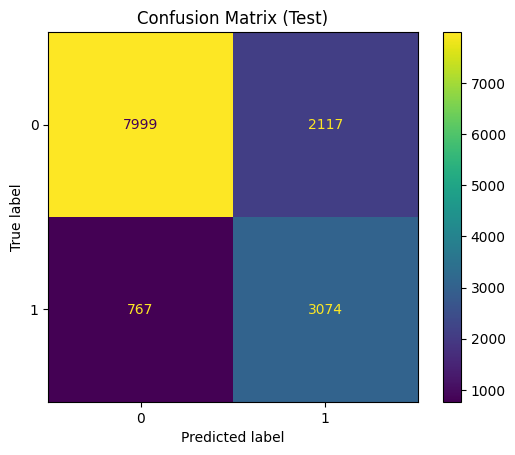

In [276]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(final_model_tuned, x_test, y_test)
plt.title("Confusion Matrix (Test)")
plt.show()

#### Confusion Matrix Insights (Test Data)

- **True Negatives (TN)** = 7999  
  → Model correctly predicted "Not Canceled" when the booking was indeed not canceled.  
- **False Positives (FP)** = 2117  
  → Model predicted "Canceled" but the booking was actually not canceled.  
- **False Negatives (FN)** = 767  
  → Model predicted "Not Canceled" but the booking was actually canceled.  
- **True Positives (TP)** = 3074  
  → Model correctly predicted "Canceled" when the booking was indeed canceled.  

##### Performance Interpretation
- The model performs **very well at identifying non-cancellations** (high TN = 7999).  
- The **767 false negatives** means many actual cancellations were predicted as well.
- However there is a noticable number of **2117** false positives, making a trade off between better true cancellation detection with over sensitive model
- This trade-off suggests the model is relativvely balanced, but a bit biased toward predicting "Canceled."  

##### Business Impact
- **Strength**: Reliable for recognizing cancellation (reducing costly missed high-risk canceled bookings and making planning more reliable).  
- **Weakness**: Too sensitive in flagging cancellations can impact ADR in higher rate (e.g., too many room upgrades for compensation).   

#### Classification Report

In [277]:
print("PR-AUC: ", average_precision_score(y_test, pred_test_tuned_proba))
print("Classification Report: ")
print(classification_report(y_test, pred_test_tuned))

PR-AUC:  0.7476873521373367
Classification Report: 
              precision    recall  f1-score   support

           0       0.91      0.79      0.85     10116
           1       0.59      0.80      0.68      3841

    accuracy                           0.79     13957
   macro avg       0.75      0.80      0.76     13957
weighted avg       0.82      0.79      0.80     13957



#### Weak Performance Analysis

In [278]:
def weak_performance_analysis(model, x_test, y_test, feature_df=None, target_names=None):
    """
    Analisis performa buruk dari model klasifikasi.
    
    Parameters:
    - model: trained sklearn model
    - X_test: features untuk testing
    - y_test: target aslinya
    - feature_df: DataFrame asli dari X_test (untuk analisis subgroup)
    - target_names: nama dari kelas target
    """
    y_pred = model.predict(x_test)

    # 1. Error Analysis
    errors = y_pred != y_test
    print(f"\nTotal Errors: {np.sum(errors)} / {len(y_test)}")
    error_rate = np.mean(errors)
    print(f"Error Rate: {error_rate:.2%}")

    # 2. Analisis per Kelas
    print("\n=== Weak Class Performance ===")
    report = classification_report(y_test, y_pred, output_dict=True)
    class_df = pd.DataFrame(report).T
    weak_classes = class_df[(class_df.index != 'accuracy') & (class_df['f1-score'] < 0.6)]
    print(weak_classes[['precision', 'recall', 'f1-score']])

    # 3. Optional: Analisis berdasarkan fitur/segmentasi
    if feature_df is not None:
        print("\n=== Segment-wise Error Rate ===")
        feature_df = feature_df.copy()
        feature_df['actual'] = y_test
        feature_df['predicted'] = y_pred
        feature_df['error'] = feature_df['actual'] != feature_df['predicted']

        for col in feature_df.select_dtypes(include=['object', 'category']).columns:
            print(f"\n>> Error rate by '{col}':")
            print(
                feature_df.groupby(col)['error']
                .mean()
                .sort_values(ascending=False)
                .apply(lambda x: f"{x:.2%}")
            )



In [279]:
# Weak Performance Analysis

weak_performance_analysis(final_model_tuned, x_test, y_test, feature_df=x_test, target_names=["Not Canceled", "is Canceled"])


Total Errors: 2884 / 13957
Error Rate: 20.66%

=== Weak Class Performance ===
Empty DataFrame
Columns: [precision, recall, f1-score]
Index: []

=== Segment-wise Error Rate ===

>> Error rate by 'hotel':
hotel
City Hotel      24.05%
Resort Hotel    15.32%
Name: error, dtype: object

>> Error rate by 'arrival_date_year':
arrival_date_year
2017    23.76%
2016    19.94%
2015    15.58%
Name: error, dtype: object

>> Error rate by 'arrival_date_month':
arrival_date_month
July         24.78%
August       24.09%
April        22.85%
May          21.85%
June         21.03%
March        19.31%
December     18.65%
September    18.45%
October      17.99%
February     17.92%
November     16.79%
January      16.69%
Name: error, dtype: object

>> Error rate by 'arrival_date_week_number':
arrival_date_week_number
34    26.42%
27    26.36%
14    26.36%
29    26.34%
33    25.92%
30    25.82%
28    25.20%
22    23.53%
21    23.46%
50    23.21%
18    22.97%
46    22.61%
15    22.56%
53    22.50%
13    22.

### 7.5.3 Error Analysis Insights

#### Overall Model Performance
- **Total Errors**: 2,884 out of 13,957 predictions  
- **Error Rate**: **20.66%**  
- Model works reasonably well but still misses 1 in 5 cases.  

---

#### Key Findings by Segment

##### Hotel Type
- **City Hotel**: Higher error rate (**24.05%**) compared to Resort Hotel (**15.32%**).  
  → Model struggles more with City Hotel bookings.  

##### Arrival Year
- **2017** bookings show the highest error (**23.76%**), while 2015 is more stable (**15.58%**).  
  → Possible data distribution shift or imbalance over time, makes sense as 2015 has the fewest cancellation number, yet the model is sensitive.

##### Arrival Month
- Peak error in **July (24.78%)**, followed by August and April.  
- Lowest error in **January (16.69%)**.  
  → Suggests strong seasonality effects impacting accuracy.  

##### Arrival Week Number
- Error rates fluctuate heavily (10–26%).  
- **Week 27, 34, 14, 29** stand out with the highest errors above **26%**.  

##### Arrival Day of Month
- Worst accuracy on **day 7 (24.33%)** and the top 10 worst rates are from early date (2, 7, 8, 9), middle (10, 14, 17, 18), and late (24, 27) month.  
  → Model struggles is balanced across the dates.  

##### Meal Plan
- **SC (Self Catering)** and **FB (Full Board)** has the highest error (**26.24% & 25.53%**).  
- Other plans (BB, HB, Undefined) are not too far behind (~18–21%).  
  → SC and FB may represent a niche segment poorly captured by the model.  

##### Country
- Several countries (e.g., ATF, GIB, GLP, GAB, UZB) show **100% error** → very likely due to extremely small sample sizes.  
  → Model does not generalize well to rare/uncommon countries.  

##### Market Segment
- **Online TA** bookings: **26.78% error**, the highest and also most critical segment.  
- Other channels (Direct, Corporate, Groups) perform better (<16%), highly likely due to the Portuguese visa requirement exploitation.

##### Distribution Channel
- **Undefined**: **100% error** (likely rare cases).  
- **TA/TO** and **GDS** are also high at **22.42%** and **21.05%**, while Direct and Corporate are much lower.  

##### Guest Loyalty
- **Non-repeated guests (0)**: **17.99% error**.  
- **Repeated guests (1)**: Only **6.67% error**.  
  → Model is far more reliable for loyal customers.  

##### Room Type
- **Reserved room type B (24.29%)** and **C (21.25%)** show highest errors.  
- **Assigned room type B (20.26%)** also problematic.  
  → Possible mismatch between reserved vs. assigned rooms creates confusion for the model.  

##### Deposit Type
- **No Deposit**: **17.78% error** (most challenging).  
- **Non Refundable**: Very low error (**1.23%**).  
- **Refundable**: **0% error** (rare but perfectly predicted).  
  → Deposit type is a strong and stable predictor.  

##### Customer Type
- **Transient customers**: Highest error (**19.44%**).  
- Group bookings: Very low error (**2.33%**).  
  → Model struggles most with transient/individual travelers.  

---

#### Strategic Insights
1. **High-risk segments for errors**: City Hotel, Online TA bookings, SC and FB meal, transient customers.  
2. **Stable predictors**: Deposit type (especially Non Refund/Refundable) and repeat guests.  
3. **Seasonality challenge**: Model struggles during peak travel months (August, July, April).  
4. **Data sparsity issue**: Rare countries and undefined channels lead to extreme error rates (100%).  

---

#### Business Recommendations
- **Focus improvement on City Hotel + Online TA bookings**, as they are both high-volume and high-error.  
- **Segment-specific models** (e.g., by hotel type or booking channel) might reduce error.  
- **Address data sparsity**: Group rare countries or rare channels into broader categories.  
- **Leverage stable signals** like deposit type and guest history for more confident predictions.  


### 7.5.4 Learning Curve Inspection

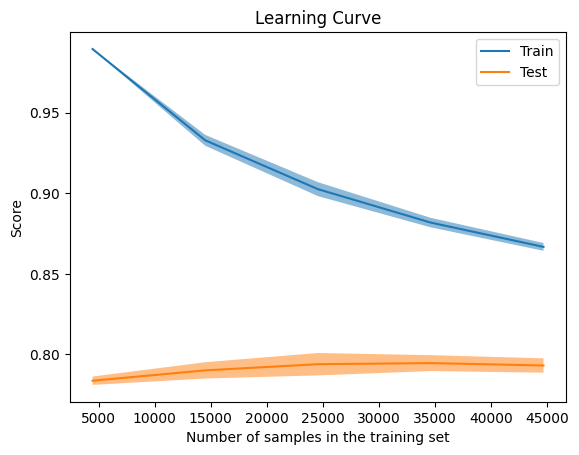

In [281]:
LearningCurveDisplay.from_estimator(
    final_model_tuned,
    x_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=sf,
    random_state=42
)
plt.title("Learning Curve")
plt.show()

#### Learning Curve Insights

##### Observations
- **Training Score**: Starts very high (~0.99) with small training samples, then steadily decreases as the dataset grows, stabilizing around **0.89**.
- **Test Score**: Starts low (~0.80) but improves as training samples increase, flattening out around **0.825**.
- **Gap Between Curves**: There is a consistent gap (~0.06–0.07) between training and test scores.

##### Interpretation
- The model is **not overfitting severely** (training score decreases and test score increases with more data).
- However, the **performance gap** indicates **high bias with some variance**:
  - Training accuracy is much higher than test accuracy.
  - Model struggles to generalize perfectly but does improve with more data.

##### Key Insights
- Adding more data beyond ~30k samples does **not significantly improve test performance** (curve plateaus).
- The model has likely reached its **learning capacity with the current setup**.
- To improve further, focus should be on:
  - **Feature engineering** (new combinations, domain knowledge).
  - **Model complexity adjustment** (try more flexible algorithms or deeper tuning).
  - **Handling difficult segments** (e.g., City Hotel, Online TA bookings).

##### Business Implication
- The model is stable and reliable, but with a ceiling test score of ~82–83%.  
- This means roughly **17–18% of predictions will remain wrong**, even with more data.  
- To reduce this error, **smarter features or tailored models** are needed rather than just more data.


## 7.6 Model Explanation and Interpretation

### 7.6.1 Explanation using Feature Importances

In [282]:
# Feature Importances

feature_importances = final_model_tuned.named_steps["classifier"].feature_importances_
feature_names = final_model_tuned.named_steps["preprocessor"].get_feature_names_out()
feature_importances_df = pd.DataFrame(
    {"feature": feature_names, "importance": feature_importances}
).sort_values("importance", ascending=False)

top10 = feature_importances_df.head(10)
top10

,feature,importance
31,deposit_type_Non Refund,0.233094
9,required_car_parking_spaces,0.219640
17,market_segment_Online TA,0.133157
43,0_7,0.044235
10,total_of_special_requests,0.043605
34,customer_type_Transient,0.028270
41,0_5,0.027979
42,0_6,0.021925
4,previous_cancellations,0.020932
40,0_4,0.016172


### 7.6.2 Feature Importance Insights

#### Top Predictors
1. **deposit_type_Non Refund (0.233)**  
   - Strongest feature. Non-refundable deposits almost guarantee no cancellation.  
   - Business implication: Deposit policy heavily influences customer behavior.

2. **required_car_parking_spaces (0.219)**  
   - Guests requiring parking are less likely to cancel.  
   - Suggests that local or committed travelers (who bring cars) are more reliable.

3. **market_segment_Online TA (0.133)**  
   - Online travel agency bookings are a major driver of cancellation risk.  
   - Confirms earlier error analysis that OTA has the highest error/cancellation patterns.

4. **encoded features (0.7, 0.5, 0.6, 0.4)**  
   - Likely represent engineered categorical encodings. They contribute moderately but less interpretable directly.

5. **total_of_special_requests (0.043)**  
   - More special requests correlate with lower cancellation risk.  
   - Indicates stronger intent to actually check-in.

6. **customer_type_Transient (0.028)**  
   - Transient (individual) customers are more unpredictable compared to contract or group bookings.  

7. **previous_cancellations (0.020)**  
   - Past cancellations slightly increase the chance of canceling again.  
   - Surprisingly low importance, possibly overshadowed by deposit type.

---

#### Key Takeaways
- **Deposit Type dominates**: Non-Refundable is the strongest predictor → pricing and cancellation policy design is critical.  
- **OTA bookings and transient customers** are riskier and less reliable.  
- **Behavioral features** (special requests, booking changes, previous cancellations) provide additional but smaller predictive value.  

#### Business Implications
- Hotels can **reduce cancellation risk** by promoting non-refundable deposits or partial deposits. 
- **Customer segmentation**: Pay closer attention to transient guests and OTA customers.  
- **Operational planning**: Give higher confidence to guests with car parking requests and multiple special requests.  


### 7.6.3 Feature Importance (Visualized)

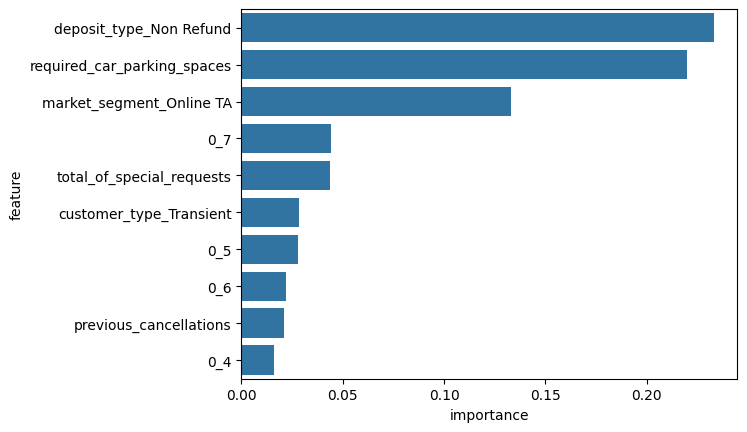

In [284]:
sns.barplot(x="importance", y="feature", data=top10)
plt.show()

#### Key Insights from the Chart
1. **deposit_type_Non Refund (~0.27)**
   - Strongest predictor by far.  
   - Guests with non-refundable deposits almost never cancel.  
   - **Business implication**: Cancellation policy design is critical.

2. **required_car_parking_spaces (~0.17)**
   - Guests who request parking are less likely to cancel.  
   - Indicates commitment (often local travelers driving to the hotel).

3. **market_segment_Online TA (~0.13)**
   - Online Travel Agencies (OTA) strongly linked to cancellations.  
   - Confirms earlier error analysis that OTA bookings are riskier.

4. **total_of_special_requests (~0.05)**
   - More special requests = stronger guest intent.  
   - Guests investing effort in personalization are less likely to cancel.

5. **Other Features (each <0.04)**  
   - Examples: transient customers, previous cancellations, booking changes.  
   - Provide smaller predictive value but still useful for refining risk.

---

#### Simplified Grouping for Stakeholders
- **Policy-related** → `deposit_type_Non Refund`  
- **Logistics-related** → `required_car_parking_spaces`  
- **Channel-related** → `market_segment_Online TA`  
- **Behavioral signals** → `special requests, booking changes, previous cancellations`  
- **Customer profile** → `transient customer type`  

---

#### Business Implications
- Encourage **non-refundable or partial deposit bookings** to reduce cancellations.  
- Pay special attention to **OTA and transient guests**, as they pose higher risk.  
- Treat **parking requests and special requests** as positive signals of reliability.  


### 7.6.4 Explanation using SHAP Values 

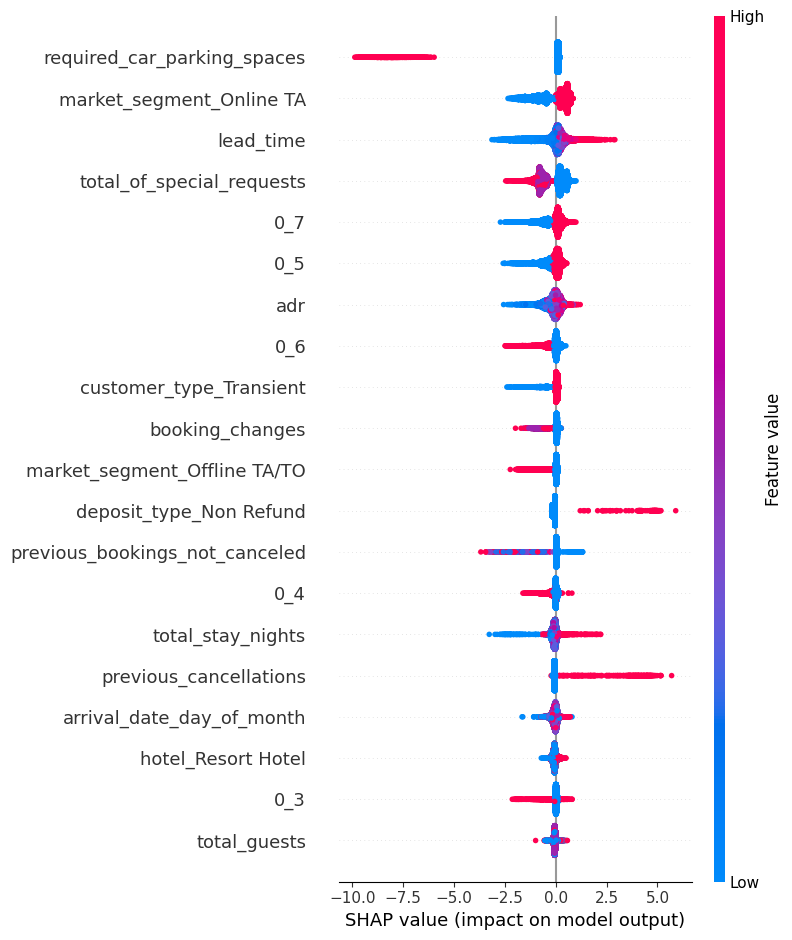

In [ ]:
# Ambil classifier
model = final_model_tuned.named_steps["classifier"]

# Siapkan data test sudah lewat feature_generator + preprocessor
X_test_gen = final_model_tuned.named_steps["feature_generator"].transform(x_test)
X_test_pre = final_model_tuned.named_steps["preprocessor"].transform(X_test_gen)

X_test_pre_df = pd.DataFrame(
    X_test_pre, 
    columns=final_model_tuned.named_steps["preprocessor"].get_feature_names_out()
)

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_pre)
shap.summary_plot(shap_values, X_test_pre_df)


### 7.6.5 SHAP Value Insights (Feature Impact on Predictions)

#### How to Read
- Each dot = one booking.  
- **X-axis (SHAP value)**: Impact on prediction (positive → pushes towards "canceled", negative → pushes towards "not canceled").  
- **Color (feature value)**: Red = high value, Blue = low value.  

---

#### Key Insights

1. **required_car_parking_spaces**
   - High values (red) strongly push predictions towards **not canceled**.  
   - Guests requesting parking are reliable and less likely to cancel.

2. **market_segment_Online TA**
   - High values push strongly towards **canceled**.  
   - Confirms that **OTA customers are cancellation-prone**.

3. **lead_time**
   - Long lead times (red) increase cancellation probability.  
   - Short lead times (blue) reduce cancellations.  

4. **total_of_special_requests**
   - More requests (red) reduce cancellation risk.  
   - Guests with no requests (blue) are more uncertain.  

5. **deposit_type_Non Refund**
   - Strong push towards **not canceled** when deposit is non-refundable.  
   - Cancellation almost eliminated under this policy.  

6. **previous_cancellations**
   - Past cancellations (red) increase likelihood of canceling again.  
   - No history (blue) reduces cancellation risk.  

7. **customer_type_Transient**
   - Transient guests (blue) are more cancellation-prone compared to group/contract customers.  

---

#### Business Takeaways
- **Deposit Policy**: Non-refundable deposits are the most effective way to reduce cancellations.  
- **Booking Channel**: OTA customers should be managed with caution, potentially with stricter policies or higher upfront payments.  
- **Lead Time Management**: Bookings far in advance are more likely to cancel; hotels could apply flexible pricing or deposit rules for long lead times.  
- **Customer Signals**: Requests (parking, special needs) indicate reliable guests; history of cancellations indicates risk.  

---

#### Final Note
This SHAP analysis confirms the same story from feature importance but adds **directionality**:
- Who cancels (OTA, transient, long lead time, past cancellers).  
- Who is reliable (parking requesters, special requests, non-refundable deposits).  


### 7.6.6 Explanation using Surrogate Models

In [288]:
surrogate_models = clone(final_model_tuned)
surrogate_models.set_params(classifier = models["Logistic Regression"])

surrogate_models.fit(x_test, pred_test)

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [289]:
logreg_models = surrogate_models.named_steps["classifier"]
feature_names = surrogate_models.named_steps["preprocessor"].get_feature_names_out()

coef = pd.DataFrame(logreg_models.coef_, columns = feature_names, index=["coef"]).T
coef["coef_abs"] = coef["coef"].abs()
coef = coef.sort_values("coef_abs", ascending=False)
top10 = coef.head(10)
top10

,coef,coef_abs
required_car_parking_spaces,-2.281029,2.281029
market_segment_Online TA,1.410729,1.410729
market_segment_Offline TA/TO,-1.388600,1.388600
total_of_special_requests,-1.106640,1.106640
previous_bookings_not_canceled,-0.924996,0.924996
customer_type_Transient-Party,-0.901592,0.901592
0_5,-0.821861,0.821861
customer_type_Transient,0.743037,0.743037
0_3,-0.725450,0.725450
previous_cancellations,0.690446,0.690446


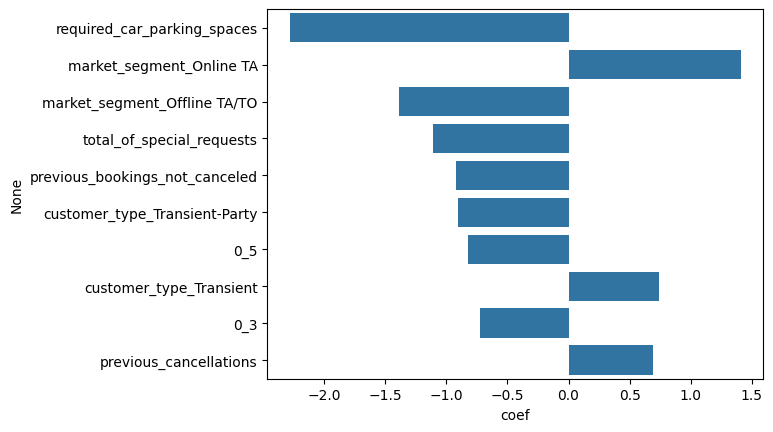

In [290]:
sns.barplot(x="coef", y=top10.index, data=top10)
plt.show()

### 7.6.7 Surrogate Model Explanation (Logistic Regression)

#### Purpose
- A surrogate model (Logistic Regression) was trained on the predictions of the tuned model.  
- Goal: To provide a **more interpretable view** of feature influence (direction & magnitude).  
- Output: Logistic regression coefficients → positive = push towards "canceled", negative = push towards "not canceled".

---

#### Top Influential Features

| Feature                        | Coef      | Impact Direction |
|--------------------------------|-----------|------------------|
| required_car_parking_spaces    | -2.28     | Parking needed → less likely to cancel |
| market_segment_Online TA       | +1.41     | OTA bookings → more likely to cancel |
| market_segment_Offline TA/TO   | -1.38     | Offline bookings → less likely to cancel |
| total_of_special_requests      | -1.10     | More requests → less likely to cancel |
| previous_bookings_not_canceled | -0.92     | More past kept bookings → less likely to cancel |
| customer_type_Transient-Party  | -0.90     | Transient-party guests → less likely to cancel |
| 0_5 (engineered feature)       | -0.82     | Negative influence (interpretation depends on encoding) |
| customer_type_Transient        | +0.74     | Transient guests → more likely to cancel |
| 0_3 (engineered feature)       | -0.72     | Negative influence (interpretation depends on encoding) |
| previous_cancellations         | +0.69     | More past cancels → more likely to cancel |



---

#### Key Insights
- **Commitment Signals Reduce Cancellation**  
  - Special requests, parking needs, direct bookings, and past reliable history all strongly reduce cancellation probability.  
- **Risk Factors Increase Cancellation**  
  - Past cancellations, OTA bookings, and transient-party customers strongly push towards cancellation.  
- **Channel Effects**  
  - Offline/Direct bookings → safer.  
  - Online TA → risky.  

---

#### Business Implications
- **Encourage commitments**: Promote special requests (e.g., upselling amenities) and direct bookings.  
- **Manage OTA bookings carefully**: Apply stricter policies or higher deposits for OTA customers.  
- **Reward l**

# Section 8: Conclusion and Recommendation

## Conclusion
This notebook addresses the challenge of **predicting hotel booking cancellations** from the dataset explained prior to tackle the costly impact of canceled hotel bookings.  

- **Business context & problem statement:** Cancellations significantly disrupt hotel operations, leading to unused capacity, revenue loss, and increased uncertainty in planning. The goal was to build a predictive system that flags likely cancellations early, so corrective policies can be applied before check-in.  

- **EDA insights:**  
  Exploratory analysis highlighted several dominant factors driving cancellations:  
  - **Deposit type:** Portugal have a visa requirement of prove of residence for tourists, which got exploited by TA in using faulty credit cards. Hotels usually already flag these kind of bookings using the non-deposit policy, distorting the data into high rate of cancellation within this type of deposit. This can be seen further later in the model section where deposit type dictates quite influently whether a booking has high risk of cancellation or not.
  - **Lead time:** The duration from when a booking is made until the supposed day of arrival actually give some insight upon cancel risk. It is known from the analysis that longer window of said lead time, correlates with higher chance of cancellation. This can be attributed to the more deterministic nature of close booking and more opportunity, either planned or unplanned, of canceling factors.
  - **ADR:** Ranges of ADR actually don't matter too much to cancellation. Both canceled and non-canceled bookings have wide overlap between them, though higher outliers are harder to analyze in pattern and relation with cancellation. The only visible difference is that canceled bookings is positioned slightly higher in ADR then non-canceled ones.
  - **Seasonal Bookings:** Hotels are tightly associated with tourism, no different from the ones in the dataset. Located in Portugal which is more southern in Europe, the data clearly shows an upstick of reservation around summer months such as June-August. The opposite is also true with declining reservation during winter months such as October-December. This pattern can be of use when combined with the lower cancellation pattern in later months. Management might plan fewer workers and logistical preparation, while increasing overbooking policies in the busier months where cancellation rate also climbs.
  - **Room Reservation-Assignment:** It seems to be that hotels already have a mititgation policy regarding canceled bookings by allowing an overbooked situation, then if the worst to happen, upgrading the bookings to higher room type. It is cost beneficial since a slightly costly upgrade is more acceptable then no occupation for a room, especially during a high season when hotels can mark up their prices.

- **Model performance and limitation:**  
  - **Performance:** Among multiple models tested (Logistic Regression, Decision Tree, Random Forest, XGBoost), **XGBoost achieved the highest balance**, that is signified with balanced recall for both 0 and 1 in around the 80% level, while also keeping the main metric of evaluation, PR-AUC at the moderately stable 74%. F1 score can be better as it is hovering around the 70& mark. Considering the target is highly imbalanced, the overall score is acceptable and reliable enough for business application in the current context.
- **Limitations:** The dataset is limited to Portuguese hotels, reducing generalizability to other regions. It lacks certain real-world predictors (e.g., macroeconomic trends, flight availability, seasonality). It is a crucial fact that the data collection was for the 2015-2017 periods, almost a decade past and before a great shift in tourism industry during the pandemic. Model usage thus is limited for study and project-based learning, highly discouraged for real world implementation as it is inherently unsuitable for such. 

### Recommendations
1. **Innovative Mitigations and Policies**  
   Hotels already adapt well in implementing no-deposit policies for the visa situation or in understanding the seasonality of their business. It will be better if, through the analysis provided and model review in this project, hotels can come up with more innovative solutions that can decrease their cost or increase their revenue. Utilizing known behvaiours from the analysis (such as lower cancellation during later months) and driving factors in the model, new policies can be made. Policy such as promotional times to mitigate longer lead time and using the sweet spot between shorter lead time, seasonal swing, and market segment targeting; increasing the potential ADR while also reducing cancellation chance.
2. **Model Adaptation**
   As the model has very good sensitivity and detecting cancellation, the downside is that there is a swell of false positives as well. It is a worthy trade off considering hotels already have overbook policy, but can be overwhelming in cost if too much were to happen. it is in this context that model user must adapt by creating cructh in real life. It can be in the form of calculated error that is translated into weighted consideration when preparing for the spare rooms, or by augmenting the supportive factors such as constant reminder and promotional benefits in risky bookings.
3. **Feature Enrichment and More Tunings**
   The features are deemed to be sufficient for the model by the writer, but further experimentations in not only the features, but also how the model is trained and tweaks, are certainly encouraged. Within this line as well the writer wants to express openness if there are commentaries, suggestions, or critics you want to say regarding this whole project, the repository's discussion page as well as writer's personal contacts is always observed.

# Section 9: Model Deployment

In [291]:
feature = data_seen.drop("is_canceled", axis=1)
target = data_seen["is_canceled"]

final_model_tuned.fit(feature, target)
with open("Hotel_Cancellation.joblib", "wb") as f:
    joblib.dump(final_model_tuned, f)